In [2]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display

import gc
import itertools

In [1]:
%%bash
ls "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"

In [3]:
base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2Dtree.root"

In [3]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def triple_secondary_vertex ( row1, row2, row3 ):
    XY1, XY2, XY3 = [to_global_coord(row1), to_global_coord(row2), to_global_coord(row3)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    x3 = XY3[0]
    y3 = XY3[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    px3 = row3["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    py3 = row3["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    pz3 = row3["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    m3 = py3/px3
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    q3 = y3 - m3*x3
    x_SV_12 = ( q2 - q1 )/( m1 - m2)
    x_SV_32 = ( q2 - q3 )/( m3 - m2)
    
    y_SV_12 = y1 + m1*(x_SV_12 - x1)
    y_SV_32 = y3 + m3*(x_SV_32 - x3)

    x_SV = (x_SV_12 + x_SV_32)/2
    y_SV = (y_SV_12 + y_SV_32)/2

    # NEW: Benedetto's fix
    z1_track = pz1/px1 * (x_SV - x1) + row1["fZ"]
    z2_track = pz2/px2 * (x_SV - x2) + row2["fZ"]
    z3_track = pz3/px3 * (x_SV - x3) + row3["fZ"]
    z_SV = (z1_track + z2_track+ z3_track)/3
    return ([x_SV, y_SV, z_SV])

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484
m_lambda = 2.28646
m_pr = 0.938272

$$
\begin{align}
\Lambda^+_c \rightarrow & p \qquad \qquad K^- \qquad \pi^+ \\
4122 \rightarrow & 2212 \quad -321 \quad +211
\end{align}
$$

In [5]:
# # NSigmaTPC:
# sigma_limit = 3
# cut1 = (
#     "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
#     "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
# )

# # NsigmaTOF:
# sigma_limit = 3
# cut2 = (
#     "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
#     "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
#     "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
# )

# # DCA_XY:
# cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# # FINAL CUT EXPRESSION:
# cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

# Run if Needed

In [6]:
collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
filtered_dfs = []

for chunk in which_chunk:
    path = base_path + "/".join(["/", chunk, which_file])
    file = uproot.open(path)

    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

    list_of_df = []               # add the dataframes in a list (we will concat them later)

    for i in range (len(names_coll)):
        # Read collision tree
        df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    
        # # Read track and trackextr using boolean mask for track and trackextr:
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka", "fNsigmaTOFpr"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
    
        # take the corresponding data of MC
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode",
                                                      "fMainMotherNfinalStateDaught","fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)
    
        # merge all rows
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
    
        # mask = df_trackextr.eval(cut_expression)        # create boolean mask
        # # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
        # df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta",
        #                                        "fCharge", "fDcaXY","fPdgCode"] ].reset_index(drop=True)

        # keep all particles that come from Lambda+ AND are either K- or pi+ or proton
        is_Lambda_plus = (df_trackextr["fMainHfMotherPdgCode"]  == +4122) & (df_trackextr["fPdgCode"].isin([-321,+211,+2212]) )
        
        df_trackextr = df_trackextr[(is_Lambda_plus) & (df_trackextr["fMainMotherNfinalStateDaught"] >= 3) ]

        # NEW: We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge","fDcaXY","fMainHfMotherPdgCode",
                                     "fMainMotherOrigIndex","fPdgCode","fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTPCpr","fNsigmaTOFpi",
                                     "fNsigmaTOFka", "fNsigmaTOFpr","fMainBeautyAncestorPdgCode","fMainMotherNfinalStateDaught"]]
    
        # we cut rows where the fIndexCollision is negative (for some reason)
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  
    
        
        # Now we for correct fPosZ (and add that column)
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
      
        df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values
    
        df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values
    
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index
    
        # save results:
        # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
        # if  i==0: df = df_trackextr
        # else: df = pd.concat([df, df_trackextr], ignore_index=True)
        # # ALTERNATIVE 2:
        list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
        
        # Update offset for next loop
        collision_offset += len(df_coll)

    # Merge everything in the total dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    
    N = len(df)
    
    # moment columns:
    df["px"] = df["fPt"] * np.cos(df["fAlpha"])
    df["py"] = df["fPt"] * np.sin(df["fAlpha"])
    df["pz"] = df["fPt"] * np.sinh(df["fEta"])
    
    # energy column: for the mass hypothesis there is uncertainty for which is the positive one: proton or pion?
    # mass = p,k, pi
    # alt_mass = pi, k, p 
    mass = np.where(df["fCharge"] == 1, m_pr, m_K)
    df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)
    alt_mass = np.where(df["fCharge"] == 1, m_pi, m_K)
    df["Alt_Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + alt_mass**2)
    
    # Debug
    print(f"The dataframe before pair computation of chunk {chunk} has", len(df), "rows and ", len(df.columns), "columns.")
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")

    # let's initialize some lists, then we will create a dataframe
    collision_indices = []
    dcaXY_products = []
    inv_masses = []
    alt_masses = []
    pt_totals = []
    pz_totals = []
    decay_lengths = []
    cos_pointings = []

    # filter variables behaviour
    TPCpi_1 = []
    TOFpi_1 = []
    
    TPCpr_1 = []
    TOFpr_1 = []

    TPCpi_2 = []
    TOFpi_2 = []
    
    TPCpr_2 = []
    TOFpr_2 = []

    TPCka = []
    TOFka = []

    # also for the fDCAXY of the two daughters
    fDcaXY_1 = []
    fDcaXY_2 = []
    fDcaXY_3 = []

    # and their transverse momentum
    pt_1 = []
    pt_2 = []
    pt_3 = []

    # MC variables
    PDG_1 = []
    PDG_2 = []
    PDG_3 = []

    Mother_1 = []
    Mother_2 = []
    Mother_3 = []

    Mother_index_1 = []
    Mother_index_2 = []
    Mother_index_3 = []
    
    counting=0 # debug variable
    
    # let's divide the dataframe for positive and negative charged
    df_pos = df[ df['fCharge']>0 ]
    df_neg = df[ df['fCharge']<0 ]
    
    # Iterate over each collision group
    for collision_idx in (df_neg['fIndexCollisions'].unique()):
        group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
        group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]
    
        # Only collisions with at least a possible triplet
        if ( (len(group_pos) < 2) or (len(group_neg) < 1) ):   continue
    
        # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
        group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
        group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})

        # We further split the positive ones in odd or even indexed ones in order to create triplets.
        group_pos1 = group_pos.iloc[::2]
        group_pos2 = group_pos.iloc[1::2]
    
        # let's crate indexes for all possible pairs:
        combinat = itertools.product( range(len(group_neg)), range(len(group_pos1)) )
    
        # Iterate over all unique pairs of tracks
        for combo in combinat:
            row_neg = group_neg.iloc[combo[0]]
            row_pos1 = group_pos1.iloc[combo[1]]

            for third_term in range (len(group_pos2)):
                # the previous selection does not reset the index, so row_pos2 has only odd-valued indexes, but iloc[n] takes the n-th row,
                # without checking the actual value of the index. So iloc[2] is the 3rd row, not the row whose index is 2
                row_pos2 = group_pos2.iloc[third_term]
    
                product_dcaXY = row_neg['fDcaXY'] * row_pos1['fDcaXY'] * row_pos2['fDcaXY']
                
                # INVARIANT MASS calculation
                pt1, pt2, pt3 = row_neg['fPt'], row_pos1['fPt'], row_pos2['fPt']
                # eta1, eta2 = row_neg['fEta'], row_pos1['fEta']
                # phi1, phi2 = row_neg['fAlpha'], row_pos1['fAlpha']
                # delta_eta = eta1 - eta2
                # delta_phi = phi1 - phi2
        
                # approximation formula
                # inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))
        
                # exact formula:
                E1 = row_pos1['Ene']
                E2 = row_pos2['Alt_Ene']
                E3 = row_neg["Ene"]
                px1 = row_pos1["px"]
                py1 = row_pos1["py"]
                pz1 = row_pos1["pz"]
                px2 = row_pos2["px"]
                py2 = row_pos2["py"]
                pz2 = row_pos2["pz"]
                px3 = row_neg["px"]
                py3 = row_neg["py"]
                pz3 = row_neg["pz"]
                inv_mass = np.sqrt( (E1+E2+E3)**2 - (px1+px2+px3)**2 - (py1+py2+py3)**2 - (pz1+pz2+pz3)**2 )
    
                # Mass for anti-D0 (use mask on mother's PDG code for histograms)
                alt_E1 = row_pos1['Alt_Ene']
                alt_E2 = row_pos2['Ene']
                alt_inv_mass = np.sqrt( (alt_E1+alt_E2+E3)**2 - (px1+px2+px3)**2 - (py1+py2+py3)**2 - (pz1+pz2+pz3)**2 )
        
                # total transverse momentum of the D0 candidate (used later for sliced plots)
                pt_total = np.sqrt((px1 + px2 + px3)**2 + (py1 + py2 + py3)**2)
        
                # secondary vertex
                SV_coords = np.array( triple_secondary_vertex(row_pos1, row_neg, row_pos2) )
        
                # decay length: distance between PV and SV
                PV_coords = np.array( [row_pos1["fPosX"], row_pos1["fPosY"], row_pos1["fPosZ"]] )
                decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )
        
                # cosine of pointing angle: the latter is the angle between the direction of the mother particle
                # and the line connecting PV and SV
                mother_direction = [px1+px2+px3, py1+py2+py3, pz1+pz2+pz3]
                flight_line = SV_coords - PV_coords
                cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
                
                # let's add the found pairs to the lists
                collision_indices.append(int(row_neg['fIndexCollisions']))
                dcaXY_products.append(product_dcaXY)
                inv_masses.append(inv_mass)
                alt_masses.append(alt_inv_mass)
                pt_totals.append(pt_total)
                pz_totals.append(pz1+pz2+pz3)
                
                pt_1.append(row_pos1['fPt'])
                TPCpi_1.append(row_pos1["fNsigmaTPCpi"])
                TOFpi_1.append(row_pos1["fNsigmaTOFpi"])
                TPCpr_1.append(row_pos1["fNsigmaTPCpr"])
                TOFpr_1.append(row_pos1["fNsigmaTOFpr"])
                fDcaXY_1.append(row_pos1["fDcaXY"])
    
                pt_2.append(row_pos2['fPt'])
                TPCpi_2.append(row_pos2["fNsigmaTPCpi"])
                TOFpi_2.append(row_pos2["fNsigmaTOFpi"])
                TPCpr_2.append(row_pos2["fNsigmaTPCpr"])
                TOFpr_2.append(row_pos2["fNsigmaTOFpr"])
                fDcaXY_2.append(row_pos2["fDcaXY"])

                pt_3.append(row_neg["fPt"])
                TPCka.append(row_neg["fNsigmaTPCka"])
                TOFka.append(row_neg["fNsigmaTOFka"])
                fDcaXY_3.append(row_neg["fDcaXY"])

                PDG_1.append(row_pos1["fPdgCode"])
                PDG_2.append(row_pos2["fPdgCode"])
                PDG_3.append(row_neg["fPdgCode"])
                
                Mother_1.append(row_pos1["fMainHfMotherPdgCode"])
                Mother_2.append(row_pos2["fMainHfMotherPdgCode"])
                Mother_3.append(row_neg["fMainHfMotherPdgCode"])
            
                Mother_index_1.append(row_pos1["fMainMotherOrigIndex"])
                Mother_index_2.append(row_pos2["fMainMotherOrigIndex"])
                Mother_index_3.append(row_neg["fMainMotherOrigIndex"])
        # # let's free the memory RAM of unused dataframes:
        # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # del group
        # gc.collect()
    
        # debug:
        counting += 1
        if counting % 50000 ==0: print(counting, end=' ')


    # create a dataframe with the result: here 1 means the first particle (so either proton or pion), 2 = kaon, 3 the opposite of 1
    df_pairs = pd.DataFrame({
        'collision_index': collision_indices,
        'dcaXY_product': dcaXY_products,
        'inv_mass': inv_masses,
        'alt_mass': alt_masses,
        'pt': pt_totals,
        'pz': pz_totals,
        'decay_length': decay_lengths,
        'cos_pointing': cos_pointings,
        'pt_1': pt_1,
        'TPCpr_1': TPCpr_1,
        'TOFpr_1': TOFpr_1,
        'TPCpi_1': TPCpi_1,
        'TOFpi_1': TOFpi_1,
        'fDcaXY_1': fDcaXY_1,
        'pt_2': pt_3,
        'TPCka': TPCka,
        'TOFka': TOFka,
        'fDcaXY_2': fDcaXY_3,
        'pt_3': pt_1,
        'TPCpr_3': TPCpr_2,
        'TOFpr_3': TOFpr_2,
        'TPCpi_3': TPCpi_2,
        'TOFpi_3': TOFpi_2,
        'fDcaXY_3': fDcaXY_2,
        'PDG_1': PDG_1,
        'PDG_2': PDG_3,
        'PDG_3': PDG_2,
        'Mother_PDG_1': Mother_1,
        'Mother_PDG_2': Mother_3,
        'Mother_PDG_3': Mother_2,
        'Mother_index_1': Mother_index_1,
        'Mother_index_2': Mother_index_3,
        'Mother_index_3': Mother_index_2
    })
    # Debug
    print(f"The final dataframe after filters and pair computation of chunk {chunk} has", len(df_pairs), "rows and ",
          len(df_pairs.columns), "columns.")
    memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")
    display( pd.concat([df_pairs.head(3),df_pairs.tail(3)]) )

    filtered_dfs.append(df_pairs)

final_results = pd.concat(filtered_dfs,ignore_index=True)

The dataframe before pair computation of chunk 001_010 has 8942 rows and  28 columns.
It occupies 1.02 MB
The final dataframe after filters and pair computation of chunk 001_010 has 399 rows and  33 columns.
It occupies 0.10 MB


,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,409,1.003012e-09,2.280883,1.946798,4.885345,-2.007151,0.232107,0.995586,1.304489,-1.832067,...,-0.002242,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,732490.0,732490.0,732490.0
1,911,-1.157561e-07,8.974739,9.127749,3.914022,-0.659005,0.020386,0.132576,4.099266,0.329508,...,0.010607,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,199083.0,198561.0,198561.0
2,1183,5.090660e-09,2.293588,2.952732,14.582443,-5.037925,0.063043,0.999683,9.279188,-0.942594,...,0.010503,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,697364.0,697364.0,697364.0
396,218206,-1.444374e-06,2.091883,2.282503,2.935262,0.263071,0.031362,0.956157,1.328850,-3.288594,...,-0.006977,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,2709746.0,2709746.0,2709746.0
397,218786,-1.732572e-07,2.741433,2.284655,4.048995,1.039505,0.296082,0.985701,0.634534,-9.687943,...,-0.001306,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,2289831.0,2289831.0,2289831.0
398,219043,-7.244792e-09,2.287100,2.674759,4.517478,-0.744684,0.004083,0.762721,2.244114,0.762947,...,-0.000725,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,2698739.0,2698739.0,2698739.0


The dataframe before pair computation of chunk 011_020 has 19038 rows and  28 columns.
It occupies 2.18 MB
The final dataframe after filters and pair computation of chunk 011_020 has 1008 rows and  33 columns.
It occupies 0.25 MB


,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,219672,-6.002552e-09,2.075373,2.273942,3.274691,1.232558,0.019871,0.955745,1.365856,0.658572,...,-0.000148,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,1022948.0,1022948.0,1022948.0
1,219971,-4.126906e-08,2.280598,2.562780,1.536269,-1.176527,0.031008,0.953255,1.336504,1.392287,...,-0.001508,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,102519.0,102519.0,102519.0
2,220410,4.183416e-04,2.006960,2.290607,4.374421,2.069497,0.887213,0.834183,2.227631,2.191019,...,0.033641,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,899427.0,899427.0,899427.0
1005,681644,-2.816611e-05,3.290474,2.265934,7.056797,4.322233,0.203031,-0.957224,0.861734,-7.131497,...,-0.040427,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,71454.0,71454.0,71454.0
1006,681747,2.737292e-09,2.266368,2.521201,2.455190,1.014745,0.012483,-0.853453,1.017431,0.412238,...,-0.003348,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,274734.0,274734.0,274734.0
1007,682142,-4.605675e-10,1.852259,2.289385,3.485872,1.699784,0.029598,-0.997765,1.983169,0.794036,...,0.001105,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,968592.0,968592.0,968592.0


The dataframe before pair computation of chunk 021_030 has 12568 rows and  28 columns.
It occupies 1.44 MB
The final dataframe after filters and pair computation of chunk 021_030 has 684 rows and  33 columns.
It occupies 0.17 MB


...

,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,2174163,4.423153e-09,1.878550,2.279720,5.737871,-1.358881,0.043296,0.998178,3.121391,2.446142,...,-0.001043,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,127629.0,127629.0,127629.0
1,2174351,4.222682e-09,2.816740,2.289371,3.099307,1.198167,0.158003,-0.725985,0.439670,-14.089359,...,-0.003812,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,438803.0,438803.0,438803.0
2,2175397,-6.400515e-08,2.289408,2.330163,4.452928,0.749131,0.023947,0.990497,2.113365,-0.965717,...,-0.004185,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,879678.0,879678.0,879678.0
814,2577260,-7.034167e-07,2.299263,2.290380,1.635249,-0.022370,0.018509,0.721189,0.695581,-8.607285,...,0.005549,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,1780275.0,1780275.0,1780275.0
815,2577530,3.334965e-09,2.284323,2.433197,1.345954,0.546451,0.012793,0.995036,0.629550,0.960531,...,-0.010357,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,2282869.0,2282869.0,2282869.0
816,2577808,-3.561767e-07,2.272846,2.839895,5.023420,-0.983546,0.030307,0.998162,2.107481,-0.049083,...,-0.015100,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,2757692.0,2757692.0,2757692.0


The dataframe before pair computation of chunk 081_090 has 16156 rows and  28 columns.
It occupies 1.85 MB
The final dataframe after filters and pair computation of chunk 081_090 has 801 rows and  33 columns.
It occupies 0.20 MB


,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,2578063,-5.144064e-09,2.273469,2.566737,11.397957,-4.728665,0.021232,0.996994,4.940247,-0.811947,...,-0.001533,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,324869.0,324869.0,324869.0
1,2579047,2.289575e-06,2.285821,2.467974,3.023969,0.386875,0.043879,0.997952,1.113518,-0.363685,...,-0.005560,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,649970.0,649970.0,649970.0
2,2579114,-1.920201e-08,2.584422,2.277935,4.589833,-0.284147,0.149754,0.996201,1.113875,-3.464799,...,-0.001495,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,759636.0,759636.0,759636.0
798,2977926,3.529552e-08,2.631347,2.296955,3.655499,0.198392,0.006741,0.250631,0.718913,-9.856215,...,-0.001156,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,2565907.0,2565907.0,2565907.0
799,2978007,2.129198e-07,2.271261,2.611013,1.746045,-1.601387,0.014828,-0.752494,1.293300,1.684634,...,0.004073,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,2715901.0,2715901.0,2715901.0
800,2979105,-4.420749e-08,2.374926,2.270067,3.104723,0.041523,0.006235,0.912735,1.084711,-4.086898,...,0.003578,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,390219.0,390219.0,390219.0


The dataframe before pair computation of chunk 091_100 has 10849 rows and  28 columns.
It occupies 1.24 MB
The final dataframe after filters and pair computation of chunk 091_100 has 501 rows and  33 columns.
It occupies 0.13 MB


,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,2982409,1.357375e-06,2.440765,2.290348,2.330508,-1.453486,0.031206,0.988398,0.786279,-6.235256,...,-0.014170,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,1239688.0,1239688.0,1239688.0
1,2983048,2.383937e-06,2.292380,2.580823,2.247745,-0.163269,0.050507,0.978745,0.865643,-0.670550,...,0.049010,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,923941.0,923941.0,923941.0
2,2983065,-6.961415e-12,2.282295,2.052140,6.134027,3.294984,0.000702,-0.941207,2.000739,-0.562783,...,-0.000085,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,959562.0,959562.0,959562.0
498,3245769,7.078156e-07,2.286207,2.328302,5.744433,-2.409166,0.136414,0.993985,2.496773,1.195911,...,0.011147,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,874540.0,874540.0,874540.0
499,3246618,-1.600325e-06,2.838272,2.290642,4.399611,3.371744,0.075872,0.974882,0.893989,-6.859763,...,-0.002869,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,2252969.0,2252969.0,2252969.0
500,3246891,-2.469041e-08,2.289704,2.389260,0.944952,-0.443843,0.028776,0.877467,0.504073,-0.401105,...,0.011512,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,2759079.0,2759079.0,2759079.0


# Load if Needed

In [4]:
final_results = pd.read_pickle("Only_Lambda_MC.pkl")
print(f"The final dataframe over all chunks has {len(final_results)} rows and {len(final_results.columns)} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results
#final_results.to_pickle("Only_Lambda_MC.pkl")

The final dataframe over all chunks has 6017 rows and 33 columns.
It occupies 1.52 MB


,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,409,1.003012e-09,2.280883,1.946798,4.885345,-2.007151,0.232107,0.995586,1.304489,-1.832067,...,-0.002242,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,732490.0,732490.0,732490.0
1,911,-1.157561e-07,8.974739,9.127749,3.914022,-0.659005,0.020386,0.132576,4.099266,0.329508,...,0.010607,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,199083.0,198561.0,198561.0
2,1183,5.090660e-09,2.293588,2.952732,14.582443,-5.037925,0.063043,0.999683,9.279188,-0.942594,...,0.010503,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,697364.0,697364.0,697364.0
3,1269,8.097440e-09,3.599101,2.282559,8.359227,-2.483511,0.039248,0.998306,0.599988,-11.223633,...,-0.003280,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,833026.0,833026.0,833026.0
4,3397,-7.548367e-07,2.273493,2.315503,1.111544,-0.000149,0.022218,-0.467287,0.739269,2.684103,...,0.019074,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,392317.0,392317.0,392317.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6012,3244940,-5.097980e-08,2.543574,2.266798,8.824228,1.929087,0.026744,0.988076,1.740738,2.033939,...,0.004812,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,800277.0,800277.0,800277.0
6013,3245449,7.619249e-08,2.634169,2.282705,2.693785,-0.099392,0.004937,0.019646,0.538929,-11.962815,...,0.005549,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,299495.0,299495.0,299495.0
6014,3245769,7.078156e-07,2.286207,2.328302,5.744433,-2.409166,0.136414,0.993985,2.496773,1.195911,...,0.011147,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,874540.0,874540.0,874540.0
6015,3246618,-1.600325e-06,2.838272,2.290642,4.399611,3.371744,0.075872,0.974882,0.893989,-6.859763,...,-0.002869,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,2252969.0,2252969.0,2252969.0


# Analysis

In [5]:
proper_order_mask = (final_results["PDG_1"]==2212) & (final_results["PDG_2"]==-321) & (final_results["PDG_3"]==+211)
reverse_order_mask = (final_results["PDG_1"]==+211) & (final_results["PDG_2"]==-321) & (final_results["PDG_3"]==+2212)
print(f"Proper order fraction: {(sum(proper_order_mask)/len(final_results)*100):.2f}%")
print(f"Reverse order fraction: {(sum(reverse_order_mask)/len(final_results)*100):.2f}%")
print(f"Neither order fraction: { (sum( (~(proper_order_mask)) & (~(reverse_order_mask)) )/len(final_results)*100):.2f}%")
print("Example of neither:")
final_results[(~(proper_order_mask)) & (~(reverse_order_mask))].head(5)

Proper order fraction: 50.87%
Reverse order fraction: 43.79%
Neither order fraction: 5.33%
Example of neither:


,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
6,4418,5.507161e-08,2.897588,3.127092,1.983712,1.540968,0.007166,-0.664484,1.045055,0.037428,...,-0.012895,2212.0,-321.0,2212.0,4122.0,4122.0,4122.0,874568.0,874568.0,874588.0
14,10158,2.486366e-07,4.028482,4.400025,0.093039,1.530522,0.025264,0.563103,1.766012,0.849290,...,-0.018602,2212.0,-321.0,2212.0,4122.0,4122.0,4122.0,2469043.0,2469797.0,2469797.0
58,32928,-2.108773e-07,2.552916,2.805616,1.514172,1.071286,0.015001,-0.745249,1.200692,1.717974,...,0.001677,2212.0,-321.0,2212.0,4122.0,4122.0,4122.0,245502.0,245513.0,245513.0
82,48728,2.598451e-03,3.055927,3.311535,1.134959,-0.132980,0.224333,0.474113,1.413694,-3.203640,...,-0.082305,211.0,-321.0,211.0,4122.0,4122.0,4122.0,1748942.0,1748814.0,1748814.0
91,60179,1.411790e-06,2.042399,2.110671,1.148026,-0.082759,0.176885,-0.874876,0.422213,-14.170392,...,0.320518,211.0,-321.0,211.0,4122.0,4122.0,4122.0,282703.0,282703.0,282770.0


In [6]:
only_valid = proper_order_mask | reverse_order_mask
df = final_results[only_valid].copy(deep=True)
df

,collision_index,dcaXY_product,inv_mass,alt_mass,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,...,fDcaXY_3,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3
0,409,1.003012e-09,2.280883,1.946798,4.885345,-2.007151,0.232107,0.995586,1.304489,-1.832067,...,-0.002242,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,732490.0,732490.0,732490.0
1,911,-1.157561e-07,8.974739,9.127749,3.914022,-0.659005,0.020386,0.132576,4.099266,0.329508,...,0.010607,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,199083.0,198561.0,198561.0
2,1183,5.090660e-09,2.293588,2.952732,14.582443,-5.037925,0.063043,0.999683,9.279188,-0.942594,...,0.010503,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,697364.0,697364.0,697364.0
3,1269,8.097440e-09,3.599101,2.282559,8.359227,-2.483511,0.039248,0.998306,0.599988,-11.223633,...,-0.003280,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,833026.0,833026.0,833026.0
4,3397,-7.548367e-07,2.273493,2.315503,1.111544,-0.000149,0.022218,-0.467287,0.739269,2.684103,...,0.019074,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,392317.0,392317.0,392317.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6012,3244940,-5.097980e-08,2.543574,2.266798,8.824228,1.929087,0.026744,0.988076,1.740738,2.033939,...,0.004812,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,800277.0,800277.0,800277.0
6013,3245449,7.619249e-08,2.634169,2.282705,2.693785,-0.099392,0.004937,0.019646,0.538929,-11.962815,...,0.005549,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,299495.0,299495.0,299495.0
6014,3245769,7.078156e-07,2.286207,2.328302,5.744433,-2.409166,0.136414,0.993985,2.496773,1.195911,...,0.011147,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,874540.0,874540.0,874540.0
6015,3246618,-1.600325e-06,2.838272,2.290642,4.399611,3.371744,0.075872,0.974882,0.893989,-6.859763,...,-0.002869,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,2252969.0,2252969.0,2252969.0


In [7]:
df["mass"] = np.where(df["PDG_1"]==2212, df["inv_mass"], df["alt_mass"])
df.drop(columns=['inv_mass', 'alt_mass'], inplace=True)
df.head()

,collision_index,dcaXY_product,pt,pz,decay_length,cos_pointing,pt_1,TPCpr_1,TOFpr_1,TPCpi_1,...,PDG_1,PDG_2,PDG_3,Mother_PDG_1,Mother_PDG_2,Mother_PDG_3,Mother_index_1,Mother_index_2,Mother_index_3,mass
0,409,1.003012e-09,4.885345,-2.007151,0.232107,0.995586,1.304489,-1.832067,1.236808,0.040323,...,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,732490.0,732490.0,732490.0,2.280883
1,911,-1.157561e-07,3.914022,-0.659005,0.020386,0.132576,4.099266,0.329508,-6.171887,-2.775901,...,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,199083.0,198561.0,198561.0,8.974739
2,1183,5.090660e-09,14.582443,-5.037925,0.063043,0.999683,9.279188,-0.942594,6.523570,-3.469018,...,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,697364.0,697364.0,697364.0,2.293588
3,1269,8.097440e-09,8.359227,-2.483511,0.039248,0.998306,0.599988,-11.223633,-60.437534,-0.451441,...,211.0,-321.0,2212.0,4122.0,4122.0,4122.0,833026.0,833026.0,833026.0,2.282559
4,3397,-7.548367e-07,1.111544,-0.000149,0.022218,-0.467287,0.739269,2.684103,-999.000000,22.629749,...,2212.0,-321.0,211.0,4122.0,4122.0,4122.0,392317.0,392317.0,392317.0,2.273493


## Lambda and couple variables

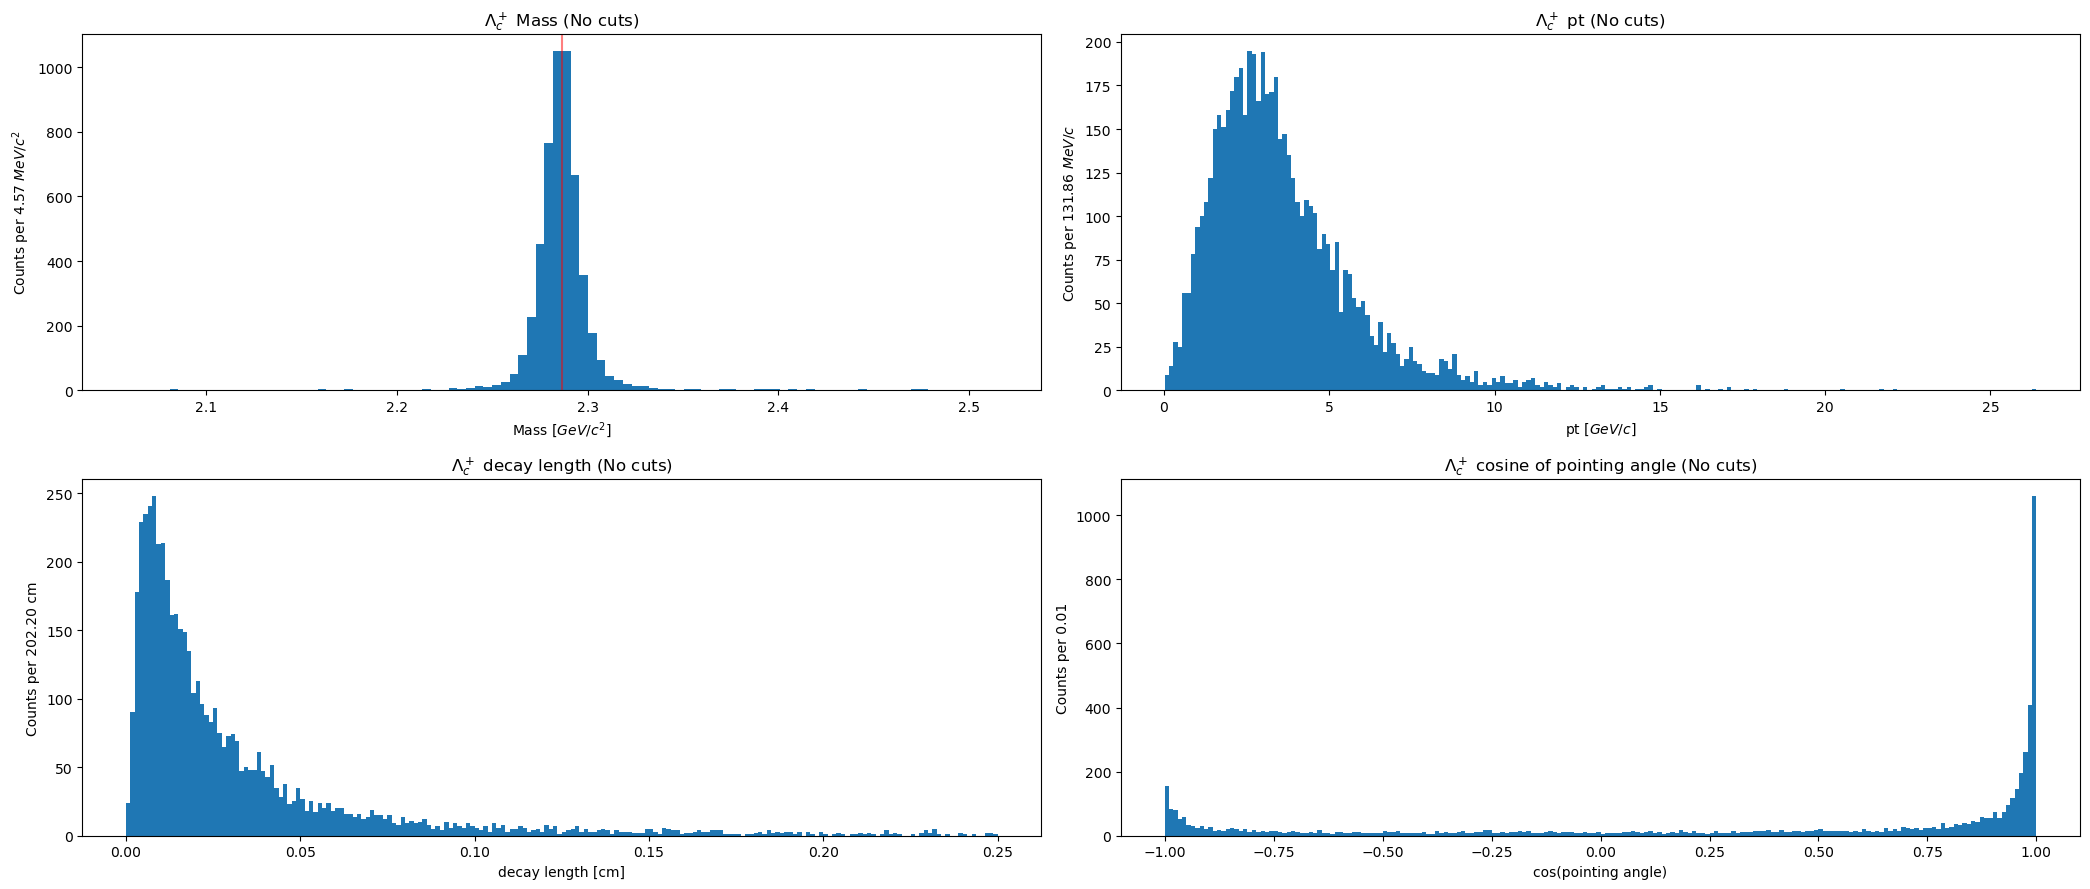

Cosine pointing angle ≥ 0.8: 51.18
Cosine pointing angle ≥ 0.9: 43.63
Cosine pointing angle ≥ 0.95: 36.34
Cosine pointing angle ≥ 0.99: 18.61


In [8]:
fig, ax = plt.subplots(2,2, figsize=(21,9))

MIN_MASS, MAX_MASS = 0.9*m_lambda, 1.1*m_lambda
N_BINS = 100
ax[0][0].hist(df["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0][0].axvline(x=m_lambda, color="red", alpha=0.5)
ax[0][0].set_xlabel("Mass [$GeV/c^2$]")
ax[0][0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0][0].set_title(r"$\Lambda^+_c$ Mass (No cuts)")

N_BINS = 200
ax[0][1].hist(df["pt"], bins=N_BINS)
ax[0][1].set_xlabel("pt [$GeV/c$]")
ax[0][1].set_ylabel(f"Counts per {((df["pt"].max()-df["pt"].min())/N_BINS)*1000:.2f} $MeV/c$")
ax[0][1].set_title(r"$\Lambda^+_c$ pt (No cuts)")

N_BINS = 200
MAX_DL = 0.25
ax[1][0].hist(df["decay_length"], bins=N_BINS,range=(0, MAX_DL))
ax[1][0].set_xlabel("decay length [cm]")
ax[1][0].set_ylabel(f"Counts per {((df["decay_length"].max()-0)/N_BINS)*1000:.2f} cm")
ax[1][0].set_title(r"$\Lambda^+_c$ decay length (No cuts)")


ax[1][1].hist(df["cos_pointing"], bins=N_BINS,range=(-1, 1))
ax[1][1].set_xlabel("cos(pointing angle)")
ax[1][1].set_ylabel(f"Counts per {((2)/N_BINS):.2f}")
ax[1][1].set_title(r"$\Lambda^+_c$ cosine of pointing angle (No cuts)")
plt.tight_layout()
plt.show()

COS_THRESHOLD = [0.80,0.90, 0.95, 0.99]
for i in range (len(COS_THRESHOLD)):
    print(f"Cosine pointing angle ≥ {COS_THRESHOLD[i]}: {((df["cos_pointing"]>=COS_THRESHOLD[i]).sum()/len(df)*100):.2f}")

## Protons

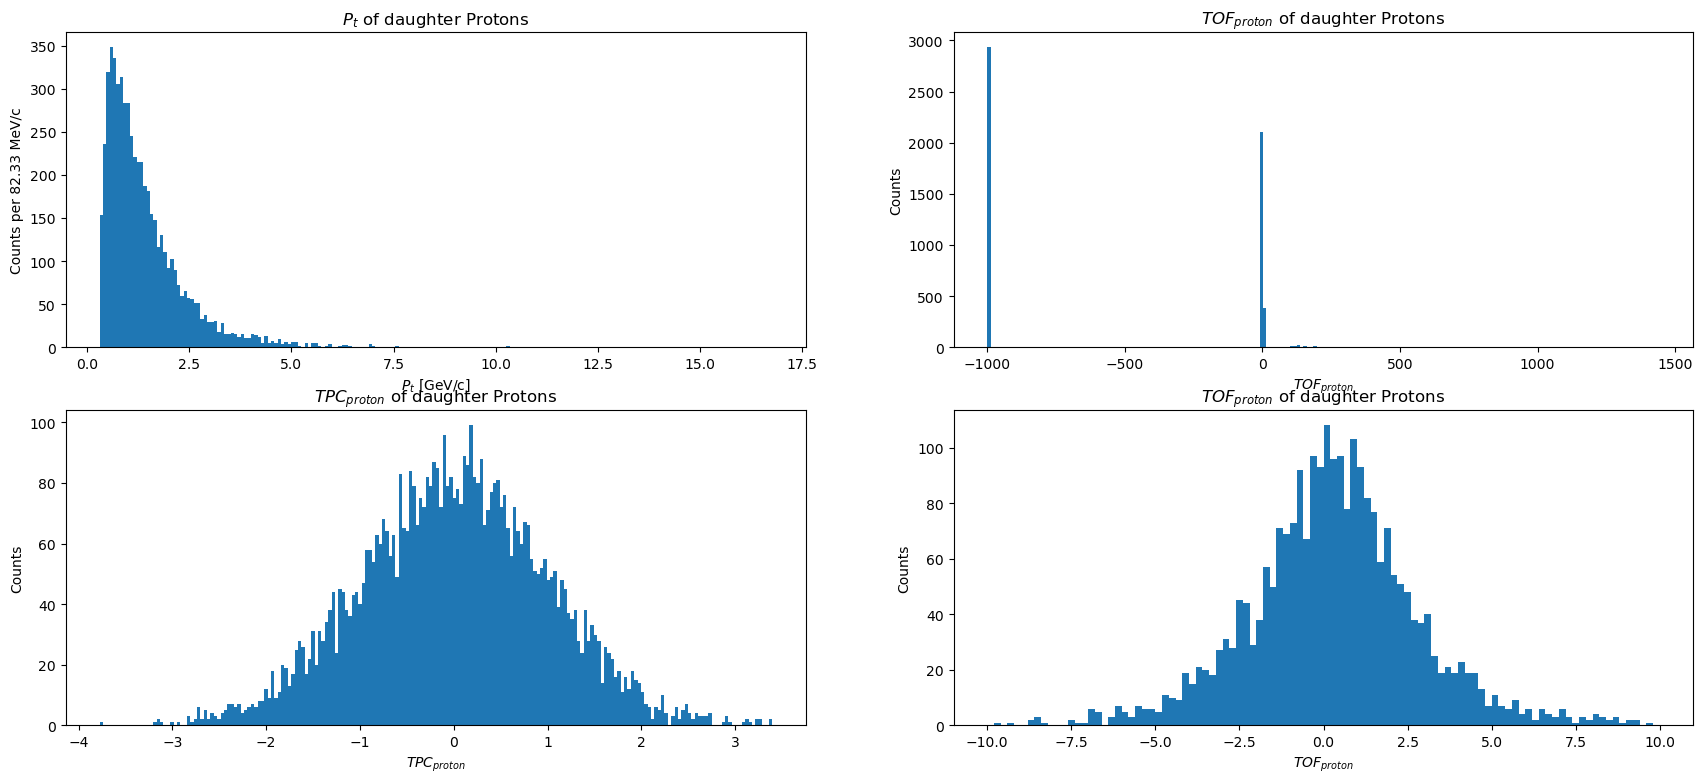

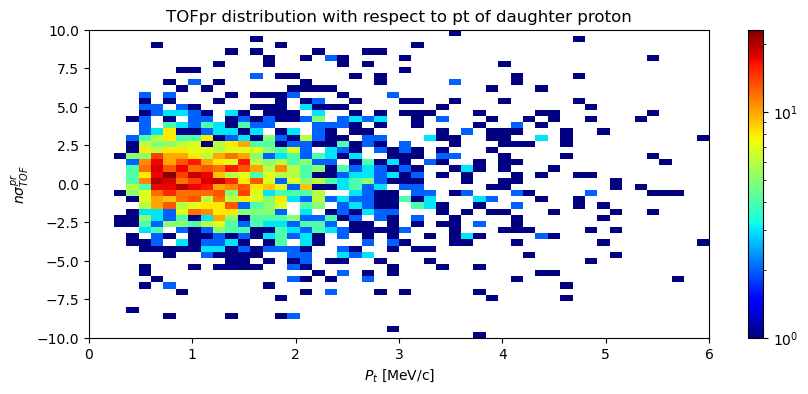

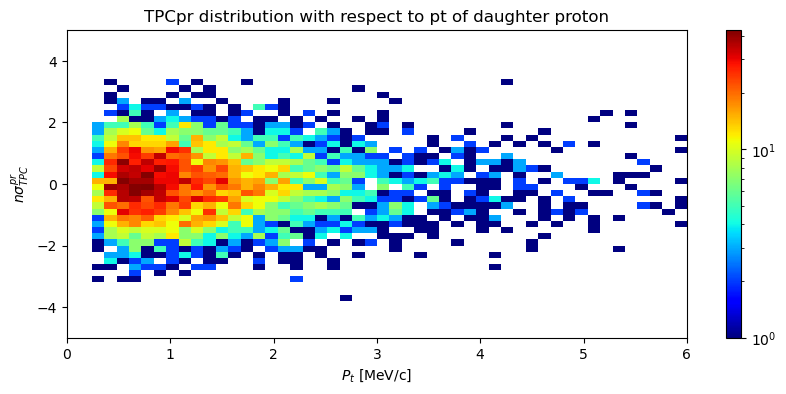

 -10 ≤ TOFpr ≤ 10: 43.66%
 -5 ≤ TOFpr ≤ 5: 41.01%
 -3 ≤ TOFpr ≤ 3: 34.69%


In [9]:
# Let's see some properties for protons
N_bin = 200
fig, ax = plt.subplots(2,2, figsize=(21,9))
pt_pr = np.where(df["PDG_1"]==2212, df["pt_1"], df["pt_3"])
ax[0][0].hist(pt_pr, bins=N_bin)
ax[0][0].set_title(f"$P_t$ of daughter Protons")
ax[0][0].set_xlabel(f"$P_t$ [GeV/c]")
ax[0][0].set_ylabel(f"Counts per {((max(pt_pr)-min(pt_pr))/N_bin*1000):.2f} MeV/c")

ax[0][1].hist( np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]), bins=N_bin )
ax[0][1].set_title(r"$TOF_{proton}$ of daughter Protons")
ax[0][1].set_xlabel(r"$TOF_{proton}$")
ax[0][1].set_ylabel(f"Counts")

ax[1][1].hist( np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]), bins=N_bin//2, range=(-10,10) )
ax[1][1].set_title(r"$TOF_{proton}$ of daughter Protons")
ax[1][1].set_xlabel(r"$TOF_{proton}$")
ax[1][1].set_ylabel(f"Counts")

ax[1][0].hist( np.where(df["PDG_1"]==2212, df["TPCpr_1"], df["TPCpr_3"]), bins=N_bin )
ax[1][0].set_title(r"$TPC_{proton}$ of daughter Protons")
ax[1][0].set_xlabel(r"$TPC_{proton}$")
ax[1][0].set_ylabel(f"Counts")

plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(pt_pr, np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{pr}_{TOF}$")
plt.title("TOFpr distribution with respect to pt of daughter proton")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(pt_pr, np.where(df["PDG_1"]==2212, df["TPCpr_1"], df["TPCpr_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{pr}_{TPC}$")
plt.title("TPCpr distribution with respect to pt of daughter proton")
plt.show()

TOF_MAX = [10,5,3]
for i in range (len(TOF_MAX)): 
    print(f" {-TOF_MAX[i]} ≤ TOFpr ≤ {TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"])) < TOF_MAX[i]))/len(df)*100:.2f}%")

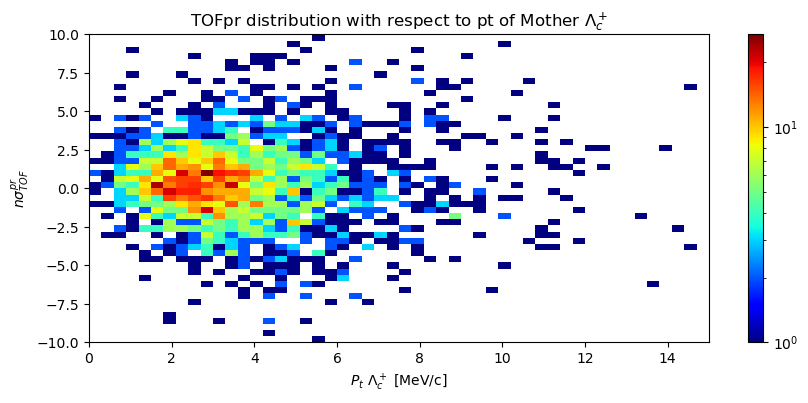

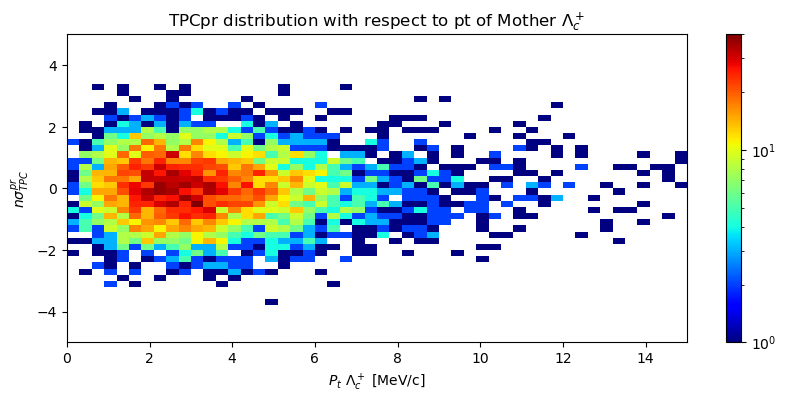

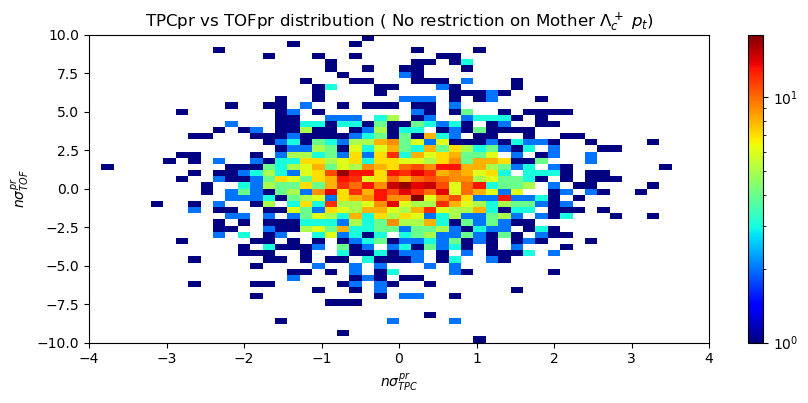

In [10]:
# What about with respect to the mother's pt?
fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt"], np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,15],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ $\Lambda^+_c$ [MeV/c]")
plt.ylabel(r"$n\sigma^{pr}_{TOF}$")
plt.title(r"TOFpr distribution with respect to pt of Mother $\Lambda^+_c$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt"], np.where(df["PDG_1"]==2212, df["TPCpr_1"], df["TPCpr_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,15],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ $\Lambda^+_c$ [MeV/c]")
plt.ylabel(r"$n\sigma^{pr}_{TPC}$")
plt.title(r"TPCpr distribution with respect to pt of Mother $\Lambda^+_c$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(np.where(df["PDG_1"]==2212, df["TPCpr_1"], df["TPCpr_3"]),np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]),
           (50, 50), cmap="jet",norm=LogNorm(), range=([-4,4],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$n\sigma^{pr}_{TPC}$")
plt.ylabel(r"$n\sigma^{pr}_{TOF}$")
plt.title(r"TPCpr vs TOFpr distribution ( No restriction on Mother $\Lambda^+_c$ $p_t$)")
plt.show()

## Negative Kaons

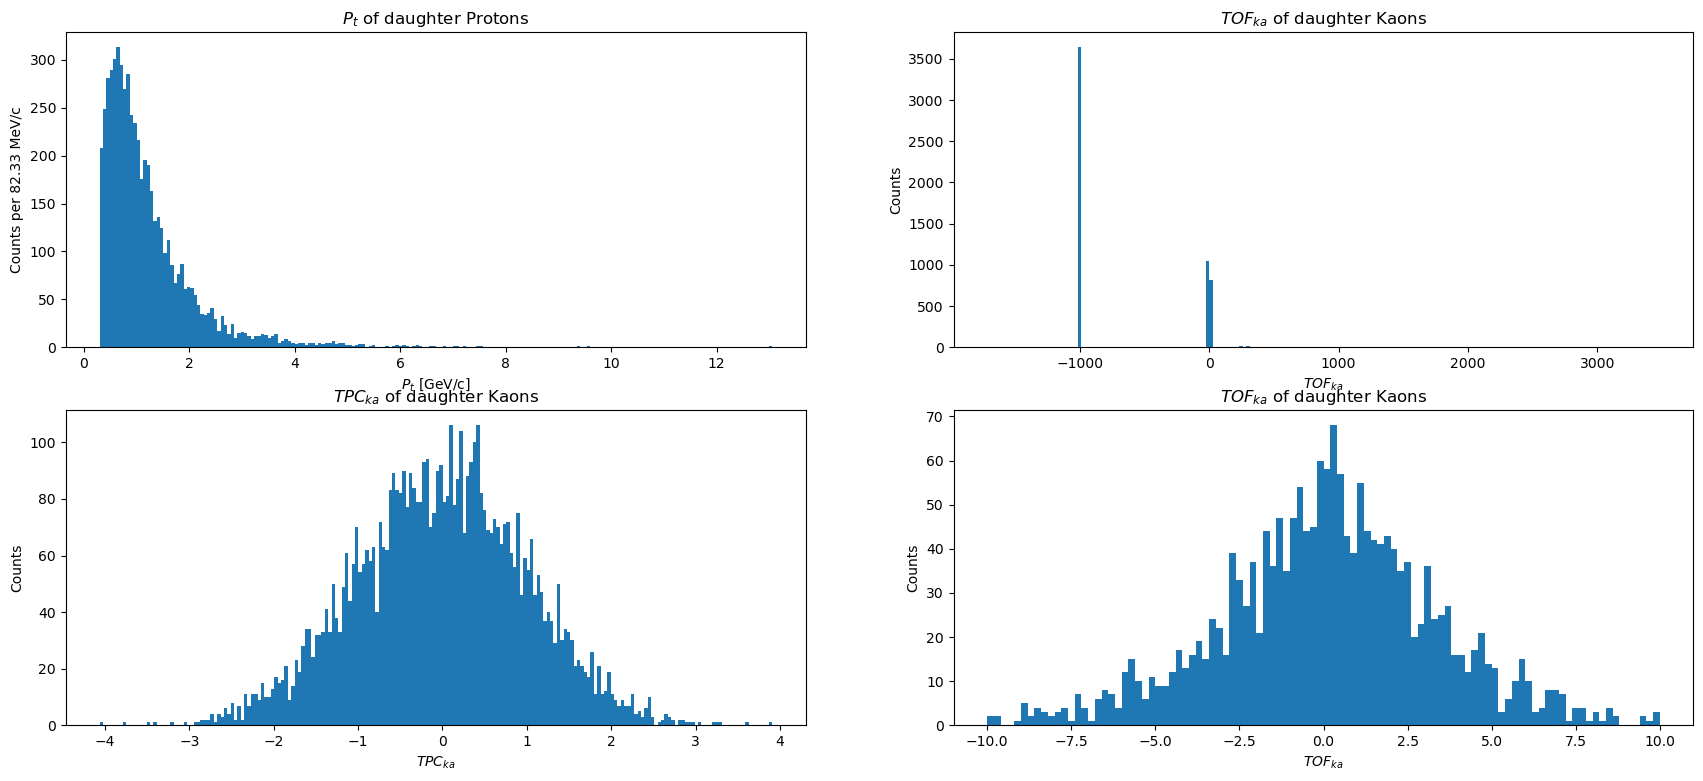

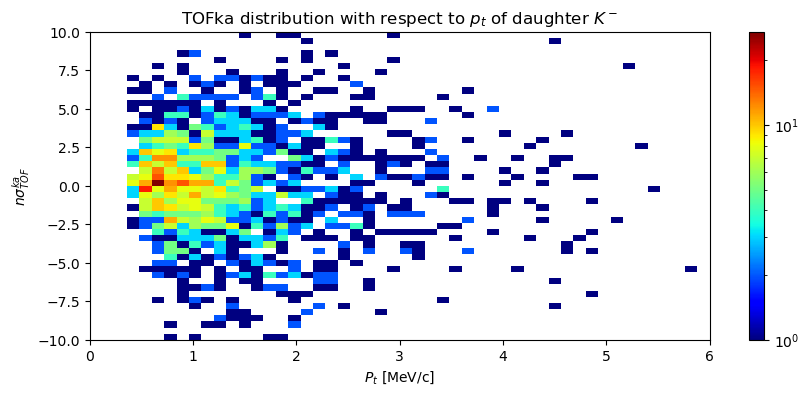

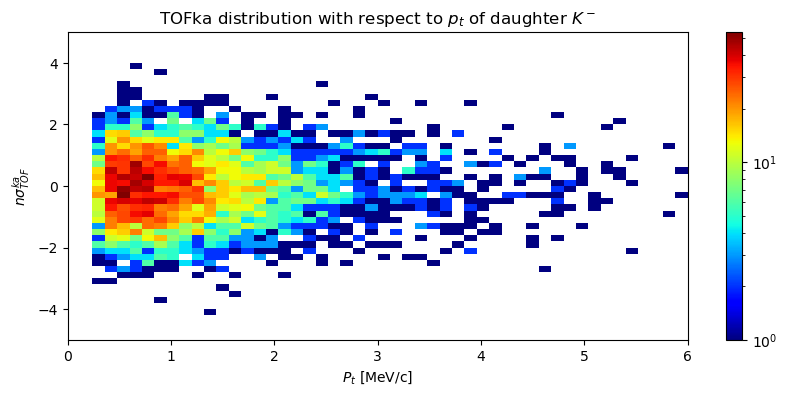

 -10 ≤ TOFka ≤ 10: 32.08%
 -5 ≤ TOFka ≤ 5: 27.98%
 -3 ≤ TOFka ≤ 3: 21.59%


In [11]:
# Let's see some properties for the negative kaons
N_bin = 200
fig, ax = plt.subplots(2,2, figsize=(21,9))
ax[0][0].hist(df["pt_2"], bins=N_bin)
ax[0][0].set_title(f"$P_t$ of daughter Protons")
ax[0][0].set_xlabel(f"$P_t$ [GeV/c]")
ax[0][0].set_ylabel(f"Counts per {((max(pt_pr)-min(pt_pr))/N_bin*1000):.2f} MeV/c")

ax[0][1].hist( df["TOFka"], bins=N_bin )
ax[0][1].set_title(r"$TOF_{ka}$ of daughter Kaons")
ax[0][1].set_xlabel(r"$TOF_{ka}$")
ax[0][1].set_ylabel(f"Counts")

ax[1][1].hist( df["TOFka"], bins=N_bin//2, range=(-10,10) )
ax[1][1].set_title(r"$TOF_{ka}$ of daughter Kaons")
ax[1][1].set_xlabel(r"$TOF_{ka}$")
ax[1][1].set_ylabel(f"Counts")

ax[1][0].hist( df["TPCka"], bins=N_bin )
ax[1][0].set_title(r"$TPC_{ka}$ of daughter Kaons")
ax[1][0].set_xlabel(r"$TPC_{ka}$")
ax[1][0].set_ylabel(f"Counts")

plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt_2"], df["TOFka"], (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$")
plt.title(r"TOFka distribution with respect to $p_t$ of daughter $K^-$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt_2"], df["TPCka"], (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$")
plt.title(r"TOFka distribution with respect to $p_t$ of daughter $K^-$")
plt.show()

TOF_MAX = [10,5,3]
for i in range (len(TOF_MAX)): 
    print(f" {-TOF_MAX[i]} ≤ TOFka ≤ {TOF_MAX[i]}: {sum(df["TOFka"].abs() < TOF_MAX[i])/len(df)*100:.2f}%")

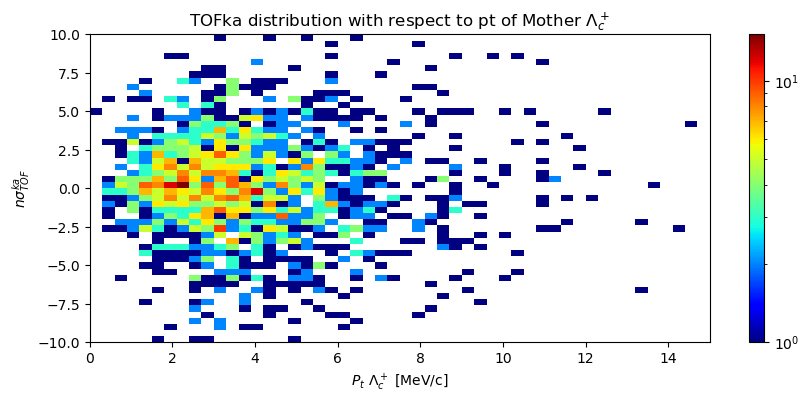

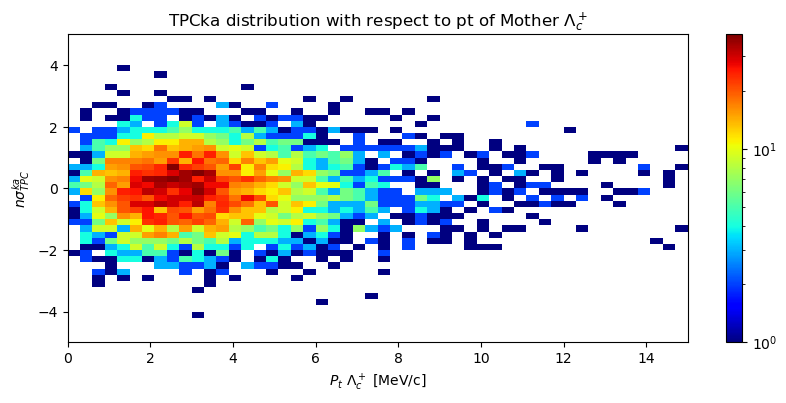

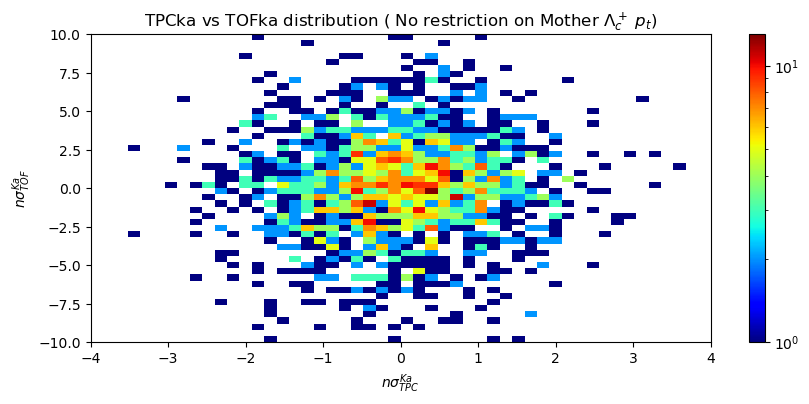

In [12]:
# What about with respect to the mother's pt?
fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt"], df["TOFka"], (50, 50), cmap="jet",norm=LogNorm(), range=([0,15],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ $\Lambda^+_c$ [MeV/c]")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$")
plt.title(r"TOFka distribution with respect to pt of Mother $\Lambda^+_c$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt"], df["TPCka"], (50, 50), cmap="jet",norm=LogNorm(), range=([0,15],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ $\Lambda^+_c$ [MeV/c]")
plt.ylabel(r"$n\sigma^{ka}_{TPC}$")
plt.title(r"TPCka distribution with respect to pt of Mother $\Lambda^+_c$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["TPCka"], df["TOFka"],(50, 50), cmap="jet",norm=LogNorm(), range=([-4,4],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$n\sigma^{Ka}_{TPC}$")
plt.ylabel(r"$n\sigma^{Ka}_{TOF}$")
plt.title(r"TPCka vs TOFka distribution ( No restriction on Mother $\Lambda^+_c$ $p_t$)")
plt.show()

## Positive Pions

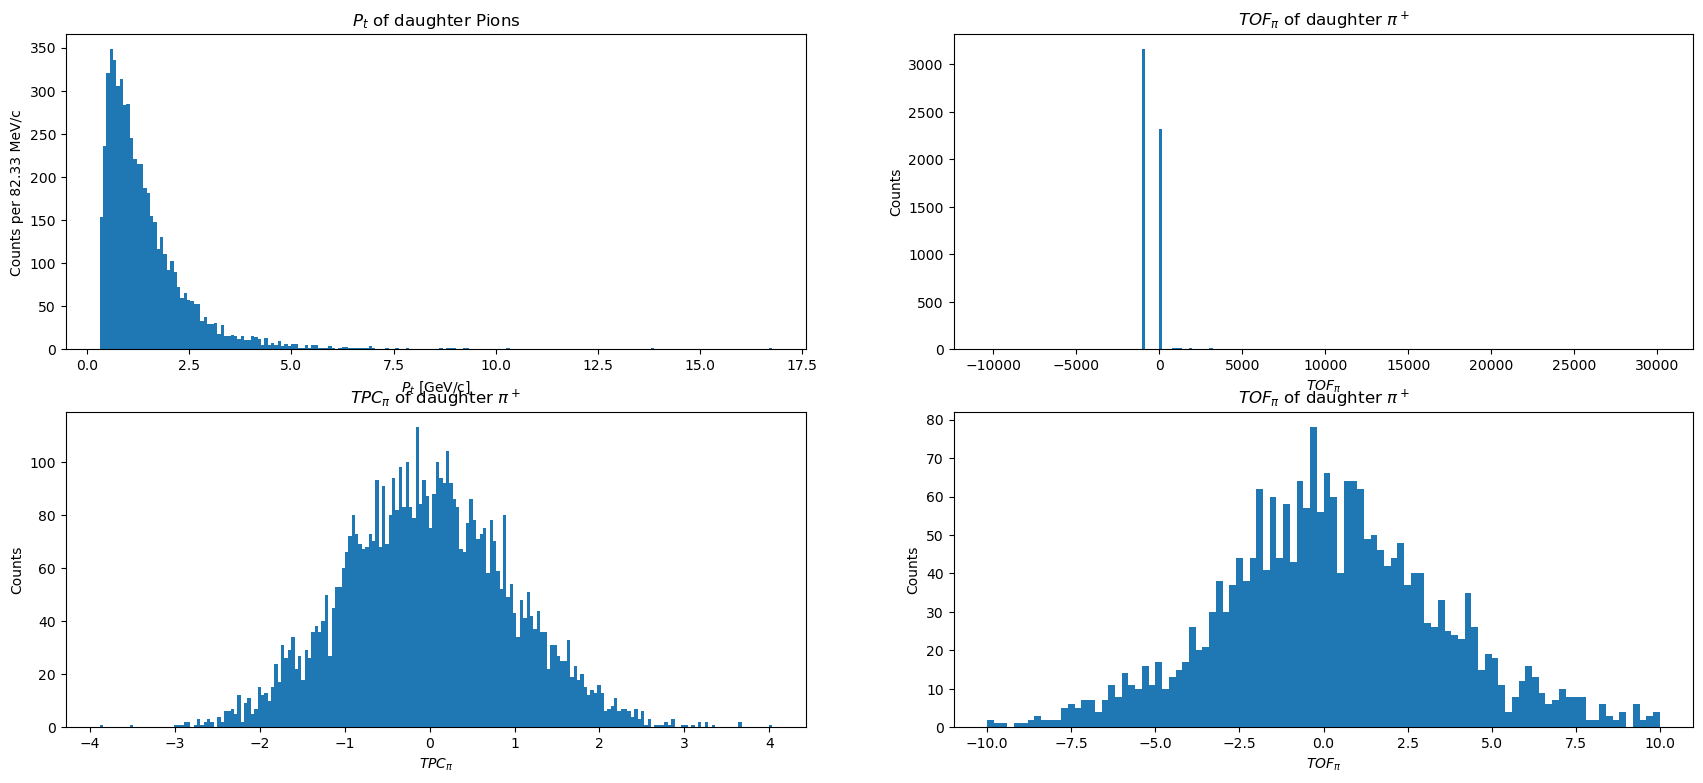

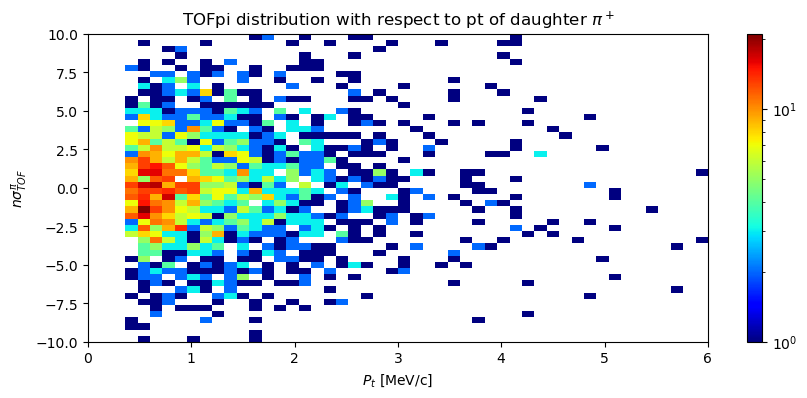

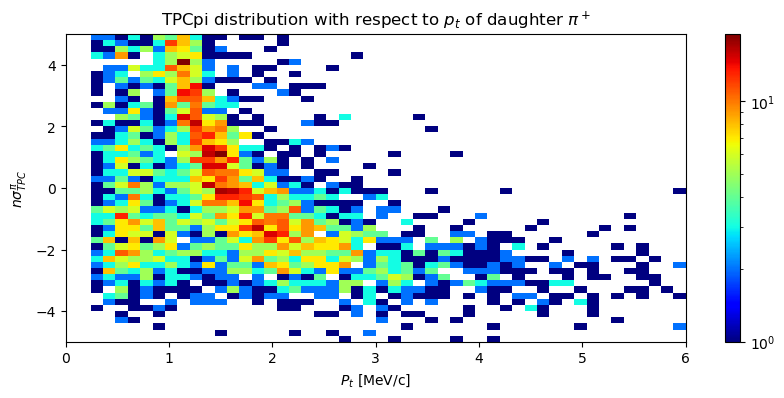

 -10 ≤ TOFpi ≤ 10: 40.01%
 -5 ≤ TOFpi ≤ 5: 34.55%
 -3 ≤ TOFpi ≤ 3: 26.47%


In [13]:
# Let's see some properties for positive pions
N_bin = 200
fig, ax = plt.subplots(2,2, figsize=(21,9))
pt_pr = np.where(df["PDG_1"]==211, df["pt_1"], df["pt_3"])
ax[0][0].hist(pt_pr, bins=N_bin)
ax[0][0].set_title(f"$P_t$ of daughter Pions")
ax[0][0].set_xlabel(f"$P_t$ [GeV/c]")
ax[0][0].set_ylabel(f"Counts per {((max(pt_pr)-min(pt_pr))/N_bin*1000):.2f} MeV/c")

ax[0][1].hist( np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]), bins=N_bin )
ax[0][1].set_title(r"$TOF_{\pi}$ of daughter $\pi^+$")
ax[0][1].set_xlabel(r"$TOF_{\pi}$")
ax[0][1].set_ylabel(f"Counts")

ax[1][1].hist( np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]), bins=N_bin//2, range=(-10,10) )
ax[1][1].set_title(r"$TOF_{\pi}$ of daughter $\pi^+$")
ax[1][1].set_xlabel(r"$TOF_{\pi}$")
ax[1][1].set_ylabel(f"Counts")

ax[1][0].hist( np.where(df["PDG_1"]==211, df["TPCpi_1"], df["TPCpi_3"]), bins=N_bin )
ax[1][0].set_title(r"$TPC_{\pi}$ of daughter $\pi^+$")
ax[1][0].set_xlabel(r"$TPC_{\pi}$")
ax[1][0].set_ylabel(f"Counts")

plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(pt_pr, np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$")
plt.title(r"TOFpi distribution with respect to pt of daughter $\pi^+$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(pt_pr, np.where(df["PDG_1"]==2212, df["TPCpi_1"], df["TPCpi_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{\pi}_{TPC}$")
plt.title(r"TPCpi distribution with respect to $p_t$ of daughter $\pi^+$")
plt.show()

TOF_MAX = [10,5,3]
for i in range (len(TOF_MAX)): 
    print(f" {-TOF_MAX[i]} ≤ TOFpi ≤ {TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"])) < TOF_MAX[i]))/len(df)*100:.2f}%")

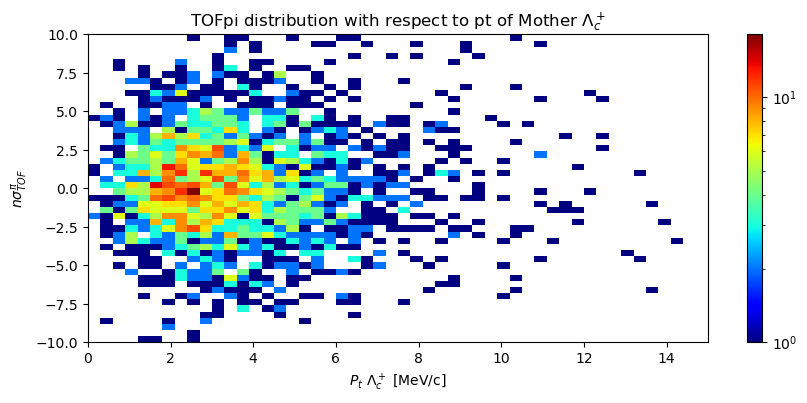

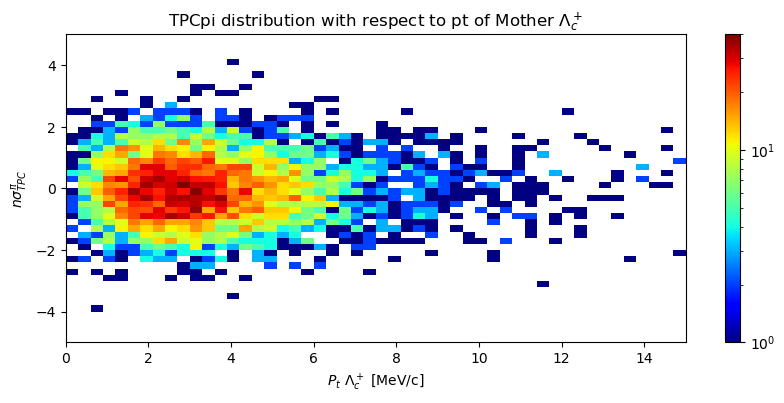

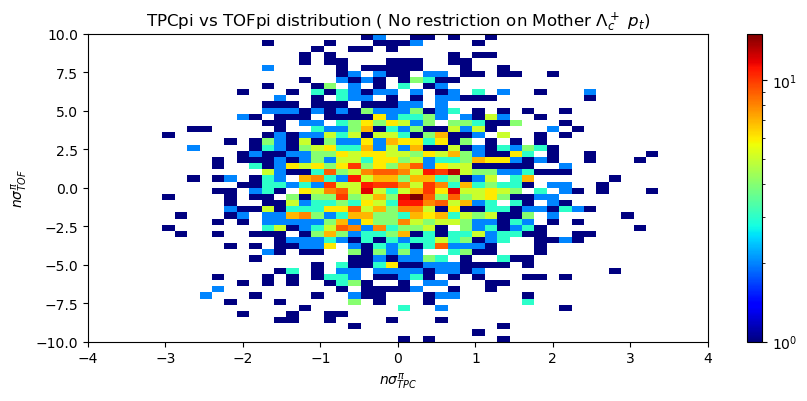

In [14]:
# What about with respect to the mother's pt?
fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt"], np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,15],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ $\Lambda^+_c$ [MeV/c]")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$")
plt.title(r"TOFpi distribution with respect to pt of Mother $\Lambda^+_c$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(df["pt"], np.where(df["PDG_1"]==211, df["TPCpi_1"], df["TPCpi_3"]), (50, 50), cmap="jet",norm=LogNorm(), range=([0,15],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ $\Lambda^+_c$ [MeV/c]")
plt.ylabel(r"$n\sigma^{\pi}_{TPC}$")
plt.title(r"TPCpi distribution with respect to pt of Mother $\Lambda^+_c$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(np.where(df["PDG_1"]==211, df["TPCpi_1"], df["TPCpi_3"]),np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]),
           (50, 50), cmap="jet",norm=LogNorm(), range=([-4,4],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$n\sigma^{\pi}_{TPC}$")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$")
plt.title(r"TPCpi vs TOFpi distribution ( No restriction on Mother $\Lambda^+_c$ $p_t$)")
plt.show()

# When we don't know which particle is which

********************************************TOF in Proton Hypothesis********************************************


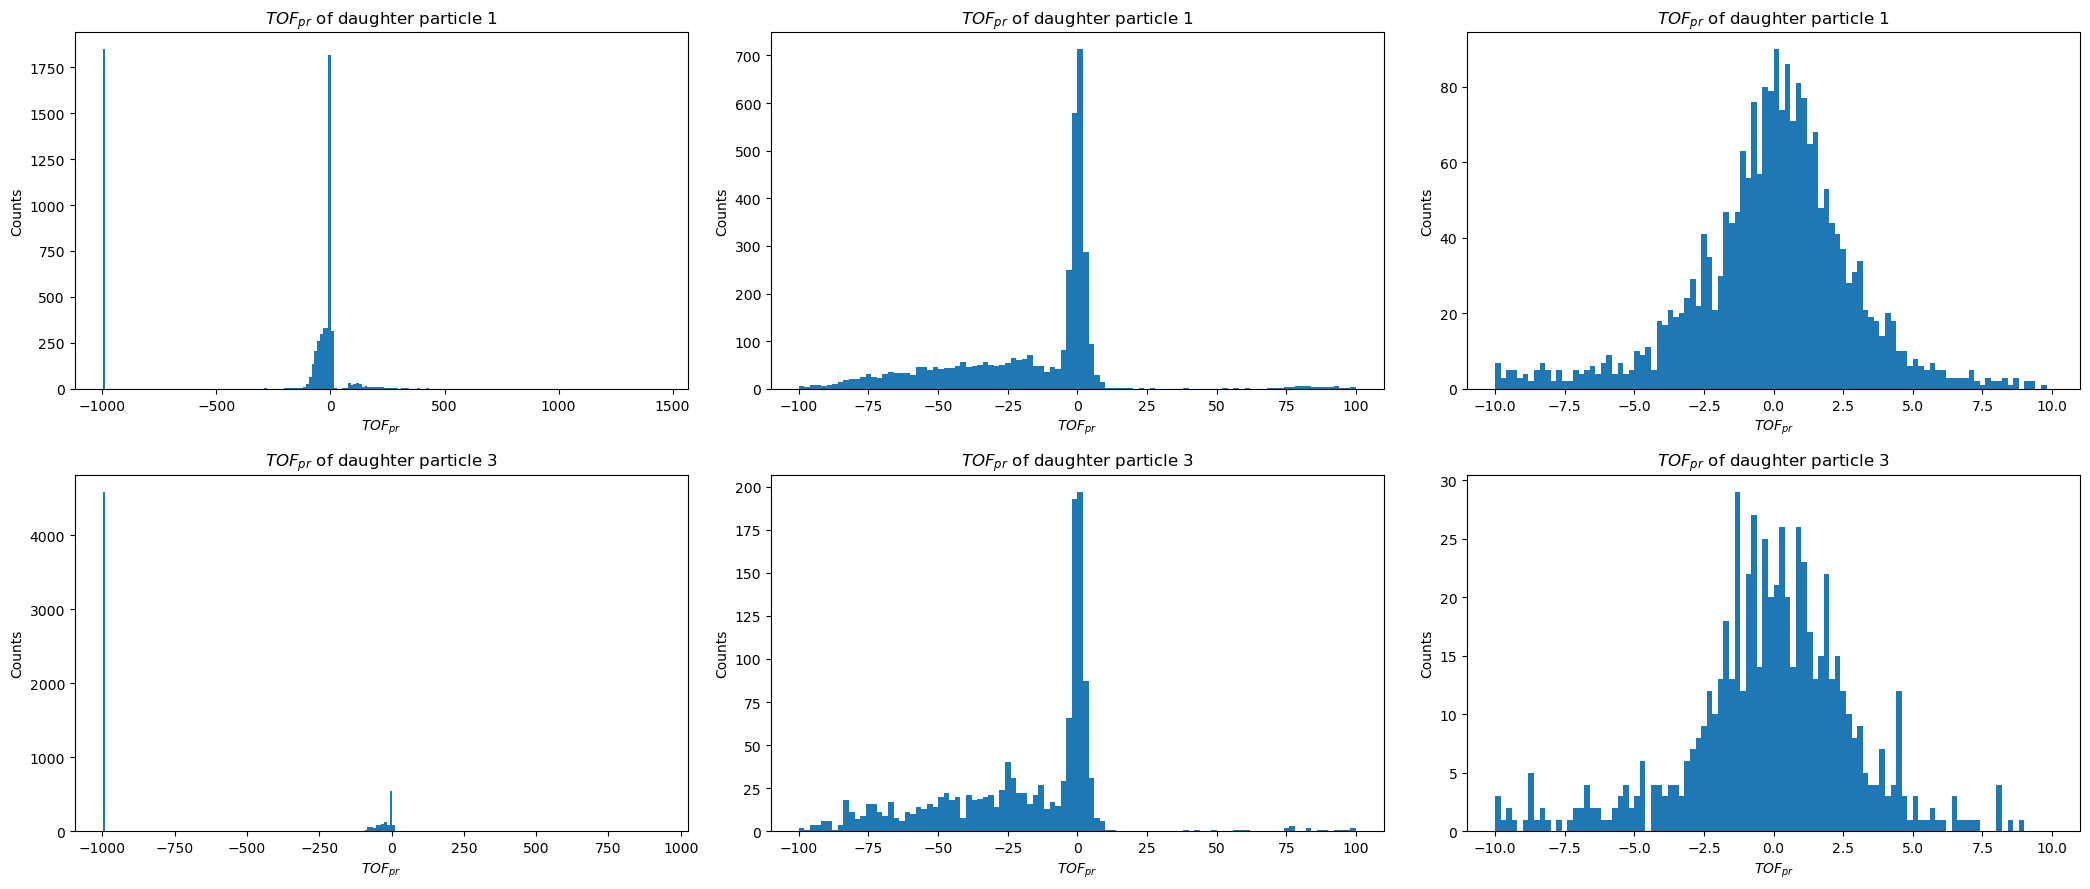

********************************************TOF in Pion Hypothesis********************************************


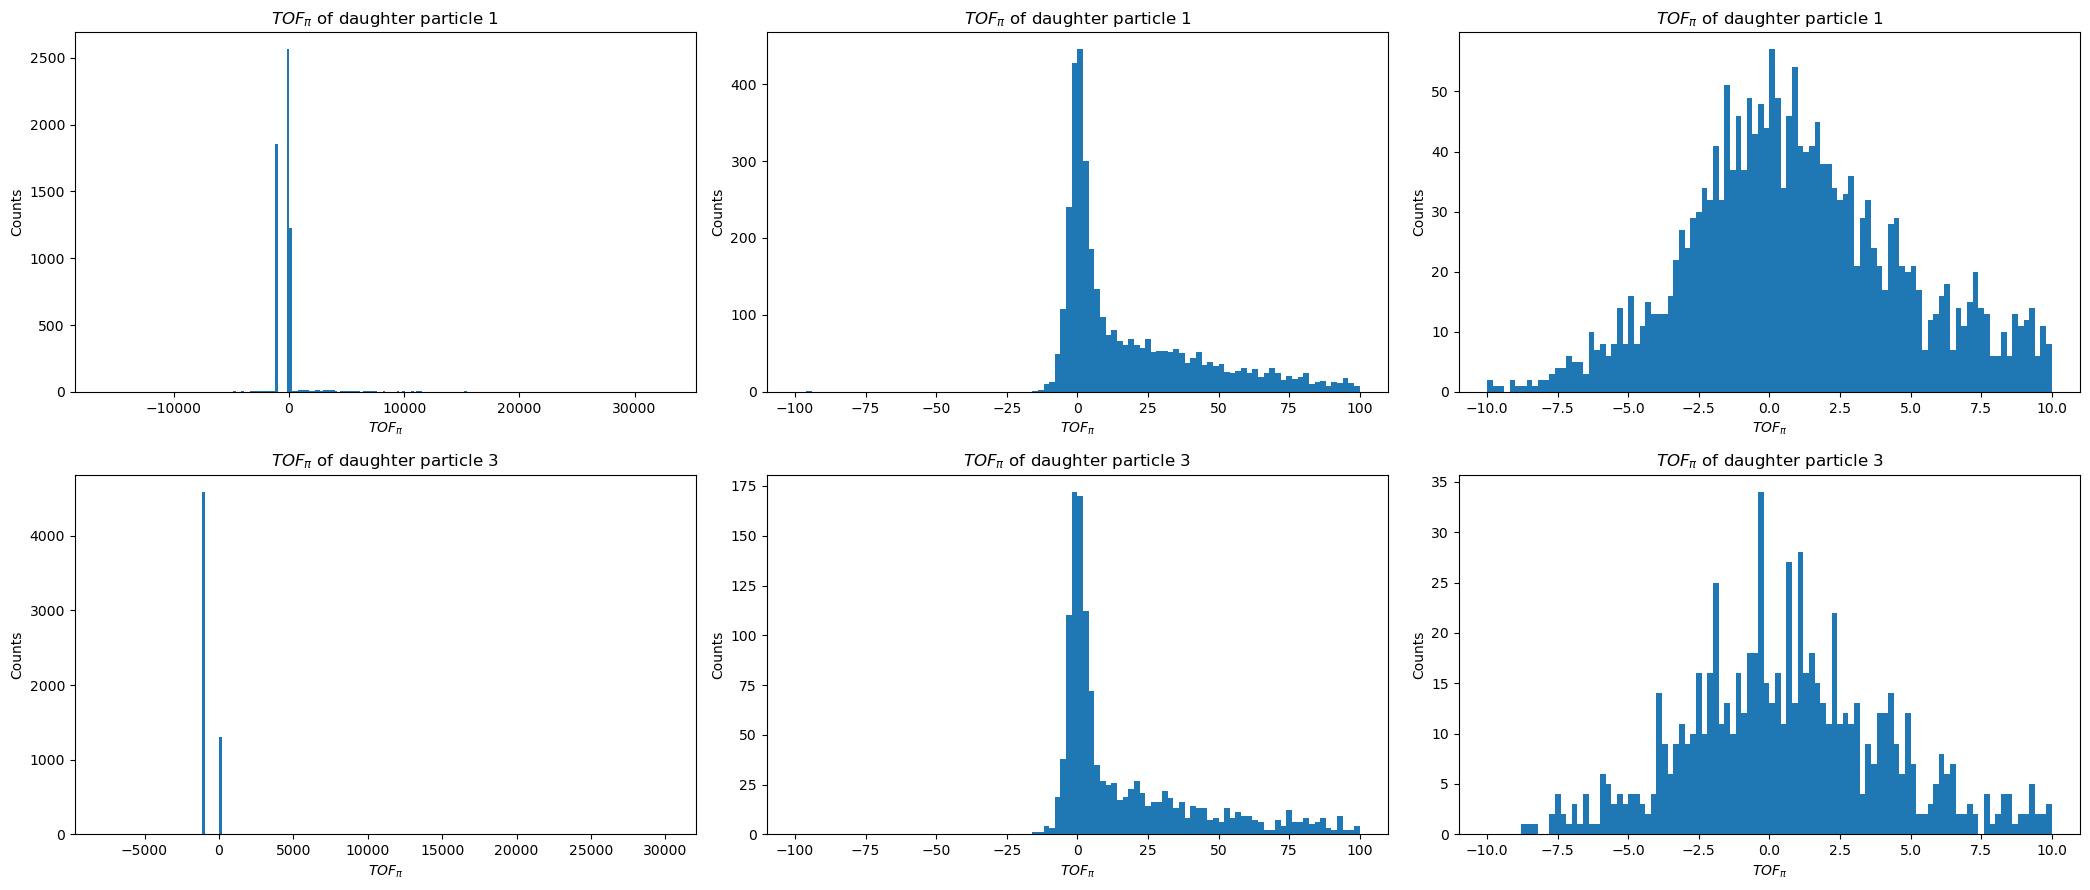

In [15]:
# How do the TOF look when we don't have the MC information?
print("********************************************TOF in Proton Hypothesis********************************************")
N_bin = 200
fig, ax = plt.subplots(2,3, figsize=(21,9))

ax[0][0].hist(final_results["TOFpr_1"], bins=N_bin )
ax[0][0].set_title(r"$TOF_{pr}$ of daughter particle 1")
ax[0][0].set_xlabel(r"$TOF_{pr}$")
ax[0][0].set_ylabel(f"Counts")

ax[0][1].hist( final_results["TOFpr_1"], bins=N_bin//2, range=(-100,100) )
ax[0][1].set_title(r"$TOF_{pr}$ of daughter particle 1")
ax[0][1].set_xlabel(r"$TOF_{pr}$")
ax[0][1].set_ylabel(f"Counts")

ax[0][2].hist( final_results["TOFpr_1"], bins=N_bin//2, range=(-10,10) )
ax[0][2].set_title(r"$TOF_{pr}$ of daughter particle 1")
ax[0][2].set_xlabel(r"$TOF_{pr}$")
ax[0][2].set_ylabel(f"Counts")

ax[1][0].hist(final_results["TOFpr_3"], bins=N_bin )
ax[1][0].set_title(r"$TOF_{pr}$ of daughter particle 3")
ax[1][0].set_xlabel(r"$TOF_{pr}$")
ax[1][0].set_ylabel(f"Counts")

ax[1][1].hist( final_results["TOFpr_3"], bins=N_bin//2, range=(-100,100) )
ax[1][1].set_title(r"$TOF_{pr}$ of daughter particle 3")
ax[1][1].set_xlabel(r"$TOF_{pr}$")
ax[1][1].set_ylabel(f"Counts")

ax[1][2].hist( final_results["TOFpr_3"], bins=N_bin//2, range=(-10,10) )
ax[1][2].set_title(r"$TOF_{pr}$ of daughter particle 3")
ax[1][2].set_xlabel(r"$TOF_{pr}$")
ax[1][2].set_ylabel(f"Counts")

plt.tight_layout()
plt.show()

print("********************************************TOF in Pion Hypothesis********************************************")
N_bin = 200
fig, ax = plt.subplots(2,3, figsize=(21,9))

ax[0][0].hist(final_results["TOFpi_1"], bins=N_bin )
ax[0][0].set_title(r"$TOF_{\pi}$ of daughter particle 1")
ax[0][0].set_xlabel(r"$TOF_{\pi}$")
ax[0][0].set_ylabel(f"Counts")

ax[0][1].hist( final_results["TOFpi_1"], bins=N_bin//2, range=(-100,100) )
ax[0][1].set_title(r"$TOF_{\pi}$ of daughter particle 1")
ax[0][1].set_xlabel(r"$TOF_{\pi}$")
ax[0][1].set_ylabel(f"Counts")

ax[0][2].hist( final_results["TOFpi_1"], bins=N_bin//2, range=(-10,10) )
ax[0][2].set_title(r"$TOF_{\pi}$ of daughter particle 1")
ax[0][2].set_xlabel(r"$TOF_{\pi}$")
ax[0][2].set_ylabel(f"Counts")

ax[1][0].hist(final_results["TOFpi_3"], bins=N_bin )
ax[1][0].set_title(r"$TOF_{\pi}$ of daughter particle 3")
ax[1][0].set_xlabel(r"$TOF_{\pi}$")
ax[1][0].set_ylabel(f"Counts")

ax[1][1].hist( final_results["TOFpi_3"], bins=N_bin//2, range=(-100,100) )
ax[1][1].set_title(r"$TOF_{\pi}$ of daughter particle 3")
ax[1][1].set_xlabel(r"$TOF_{\pi}$")
ax[1][1].set_ylabel(f"Counts")

ax[1][2].hist( final_results["TOFpi_3"], bins=N_bin//2, range=(-10,10) )
ax[1][2].set_title(r"$TOF_{\pi}$ of daughter particle 3")
ax[1][2].set_xlabel(r"$TOF_{\pi}$")
ax[1][2].set_ylabel(f"Counts")

plt.tight_layout()
plt.show()

## Is a cross-check for the TOF/TPC variables useful for PID?

### Protons

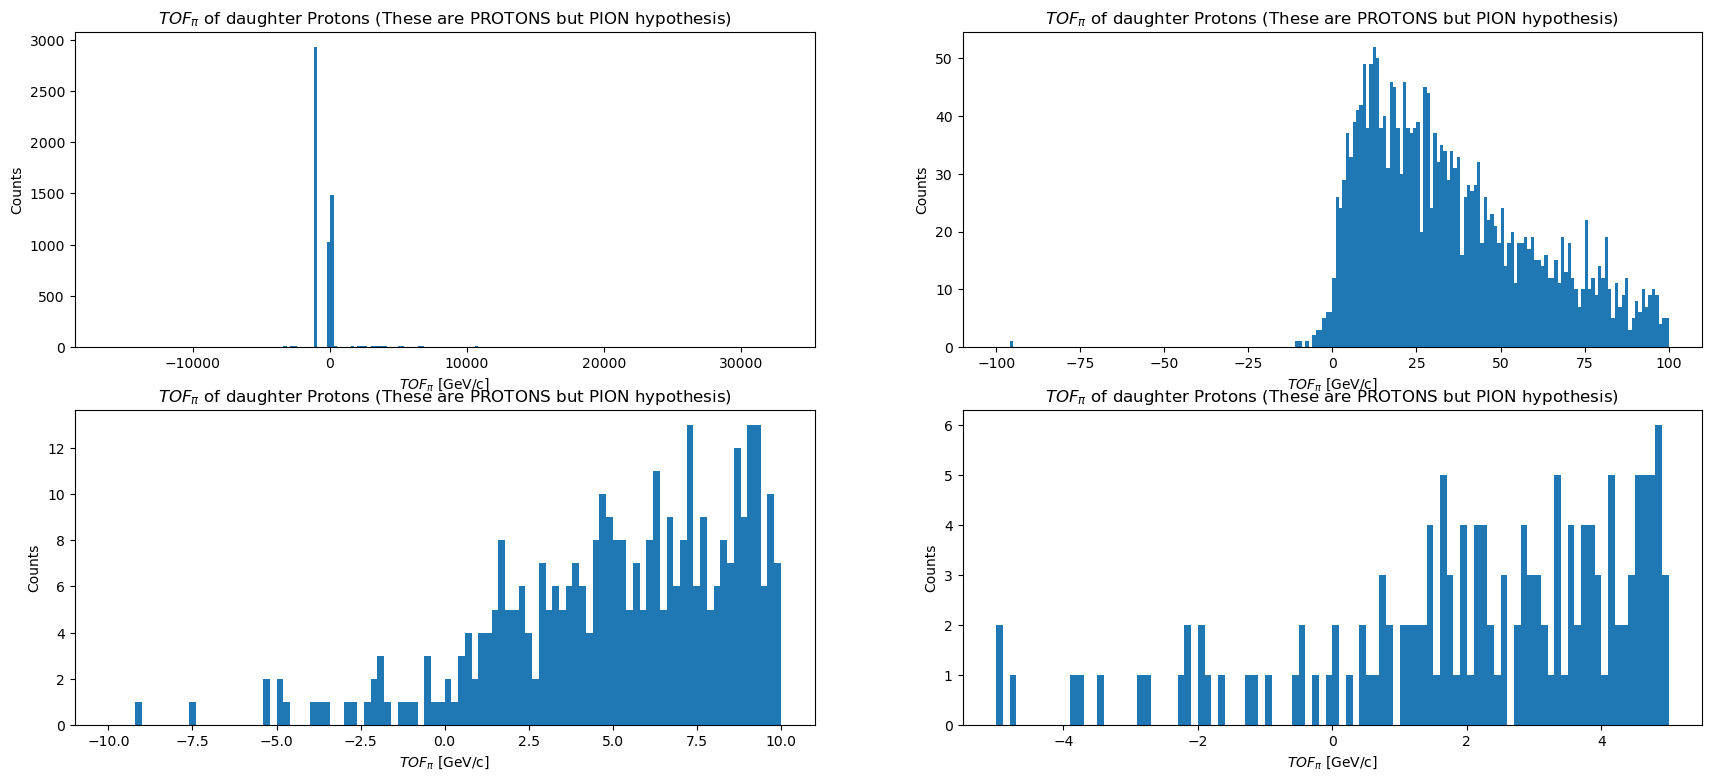

The fraction of PROTONS with unavailable TOFpr is: 51.46%
 -10 ≤ TOFpr ≤ 10: 43.66%
 -5 ≤ TOFpr ≤ 5: 41.01%
 -3 ≤ TOFpr ≤ 3: 34.69%

Out of those with TOF within 10 sigmas
 -5 ≤ TOFpr ≤ 5: 93.93%
 -3 ≤ TOFpr ≤ 3: 79.45%

The fraction of PROTONS with unavailable TOFpi is: 51.46%
For these particles (Truth=Proton, but Pion hyp): of those with |TOFpi| within 100 sigmas
 -100 ≤ TOFpi ≤ 100: 100.00%
 -50 ≤ TOFpi ≤ 50: 73.54%
 -25 ≤ TOFpi ≤ 25: 42.27%
 -10 ≤ TOFpi ≤ 10: 15.55%
 -5 ≤ TOFpi ≤ 5: 6.54%
 -3 ≤ TOFpi ≤ 3: 3.42%
 -1 ≤ TOFpi ≤ 1: 0.78%


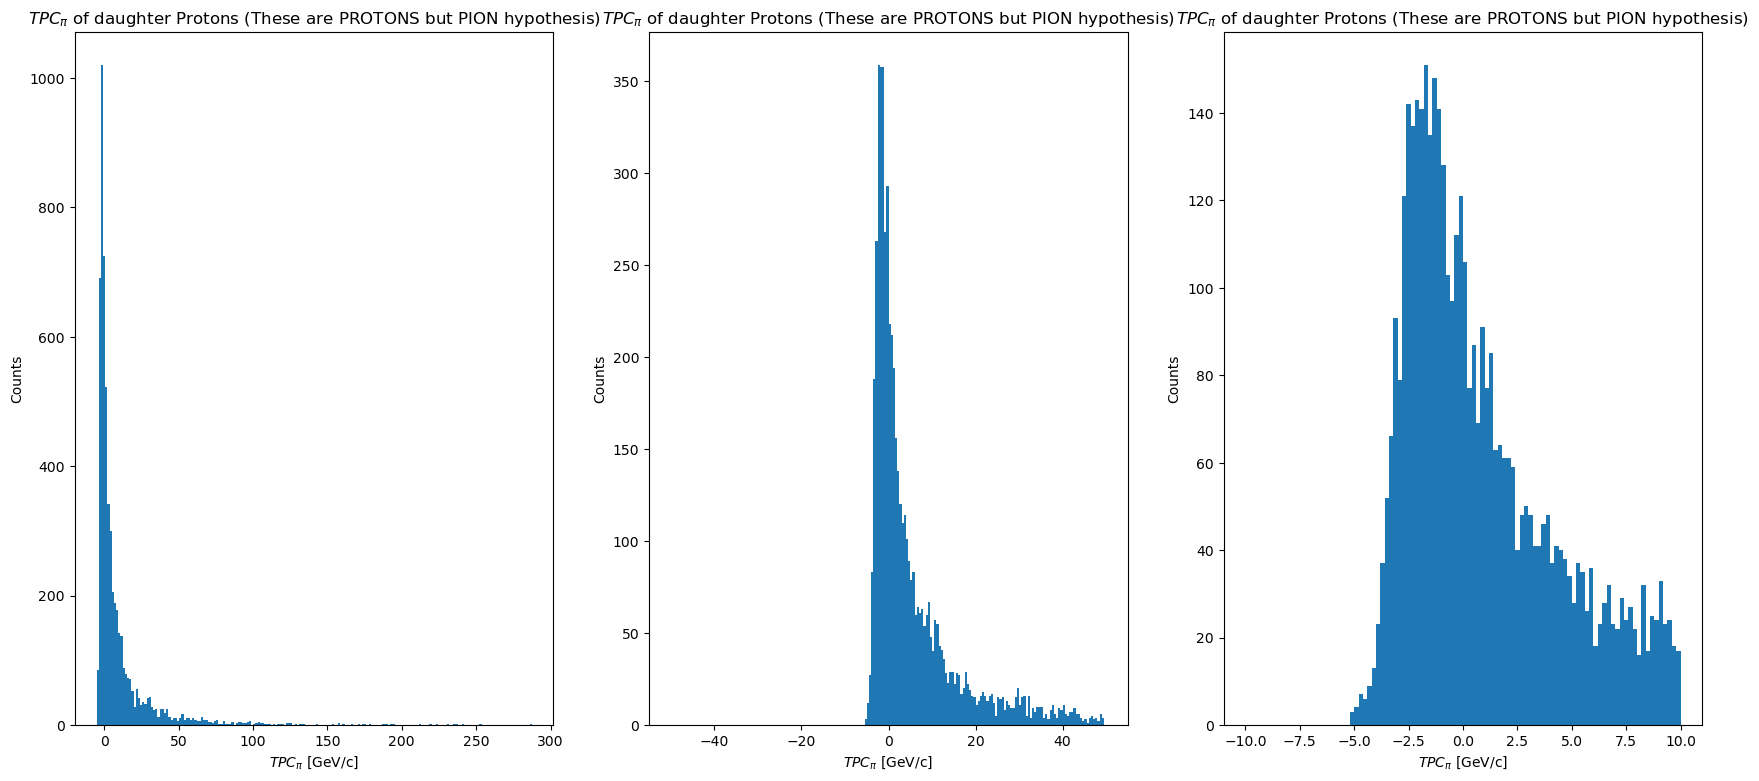

Protons crosscheck with TPCpi:
-10 ≤ TPCpi ≤ 10:     75.54%
-5 ≤ TPCpi ≤ 5:     64.27%
-3 ≤ TPCpi ≤ 3:     51.56%
-1 ≤ TPCpi ≤ 1:     17.40%


In [16]:
# these are protons(2212) but I check the variables relative to pions to see if they are easy to spot
# Let's see some properties for protons
N_bin = 200
fig, ax = plt.subplots(2,2, figsize=(21,9))
ax[0][0].hist(np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"]), bins=N_bin)
ax[0][0].set_title(r"$TOF_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[0][0].set_xlabel(r"$TOF_{\pi}$ [GeV/c]")
ax[0][0].set_ylabel(f"Counts")

ax[0][1].hist(np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"]), bins=N_bin, range=(-100,100))
ax[0][1].set_title(r"$TOF_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[0][1].set_xlabel(r"$TOF_{\pi}$ [GeV/c]")
ax[0][1].set_ylabel(f"Counts")

ax[1][0].hist(np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"]), bins=N_bin//2, range=(-10,10))
ax[1][0].set_title(r"$TOF_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[1][0].set_xlabel(r"$TOF_{\pi}$ [GeV/c]")
ax[1][0].set_ylabel(f"Counts")

ax[1][1].hist(np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"]), bins=N_bin//2, range=(-5,5))
ax[1][1].set_title(r"$TOF_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[1][1].set_xlabel(r"$TOF_{\pi}$ [GeV/c]")
ax[1][1].set_ylabel(f"Counts")
plt.show()


# Let's crunch some numbers
print("The fraction of PROTONS with unavailable TOFpr is: "+
     f"{(sum(np.isclose((np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"])),-999)))/len(df)*100:.2f}%")

TOF_MAX = [10,5,3]
for i in range (len(TOF_MAX)): 
    print(f" {-TOF_MAX[i]} ≤ TOFpr ≤ {TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"])) < TOF_MAX[i]))/len(df)*100:.2f}%")

print("\nOut of those with TOF within 10 sigmas")
for i in [1,len(TOF_MAX)-1]: 
    print(f" {-TOF_MAX[i]} ≤ TOFpr ≤ {TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"])) < TOF_MAX[i]))
    /(sum(np.abs(np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]))<=10))*100:.2f}%")

print("\nThe fraction of PROTONS with unavailable TOFpi is: "+
     f"{(sum(np.isclose((np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"])),-999)))/len(df)*100:.2f}%")
EX_TOF_MAX = [100,50,25,10,5,3,1]
print("For these particles (Truth=Proton, but Pion hyp): of those with |TOFpi| within 100 sigmas")
for i in range (len(EX_TOF_MAX)): 
    print(f" {-EX_TOF_MAX[i]} ≤ TOFpi ≤ {EX_TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"])) < EX_TOF_MAX[i]))
                                                             /(sum(np.abs(np.where(df["PDG_1"]==2212, df["TOFpi_1"], df["TOFpi_3"]))<=100))*100:.2f}%")

fig, ax = plt.subplots(1,3, figsize=(21,9))
ax[0].hist(np.where(df["PDG_1"]==2212, df["TPCpi_1"], df["TPCpi_3"]), bins=N_bin)
ax[0].set_title(r"$TPC_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[0].set_xlabel(r"$TPC_{\pi}$ [GeV/c]")
ax[0].set_ylabel(f"Counts")

ax[1].hist(np.where(df["PDG_1"]==2212, df["TPCpi_1"], df["TPCpi_3"]), bins=N_bin, range=(-50,50))
ax[1].set_title(r"$TPC_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[1].set_xlabel(r"$TPC_{\pi}$ [GeV/c]")
ax[1].set_ylabel(f"Counts")

ax[2].hist(np.where(df["PDG_1"]==2212, df["TPCpi_1"], df["TPCpi_3"]), bins=N_bin//2, range=(-10,10))
ax[2].set_title(r"$TPC_{\pi}$ of daughter Protons (These are PROTONS but PION hypothesis)")
ax[2].set_xlabel(r"$TPC_{\pi}$ [GeV/c]")
ax[2].set_ylabel(f"Counts")

plt.show()

print("Protons crosscheck with TPCpi:")
TPC_THR = [10,5,3,1]
for i in range (len(TPC_THR)):
    print(f"{-TPC_THR[i]} ≤ TPCpi ≤ {TPC_THR[i]}: \
    {sum((np.abs(np.where(df["PDG_1"]==2212, df["TPCpi_1"], df["TPCpi_3"])) <= TPC_THR[i]))/len(df)*100:.2f}%" )

### Unavailable TOF

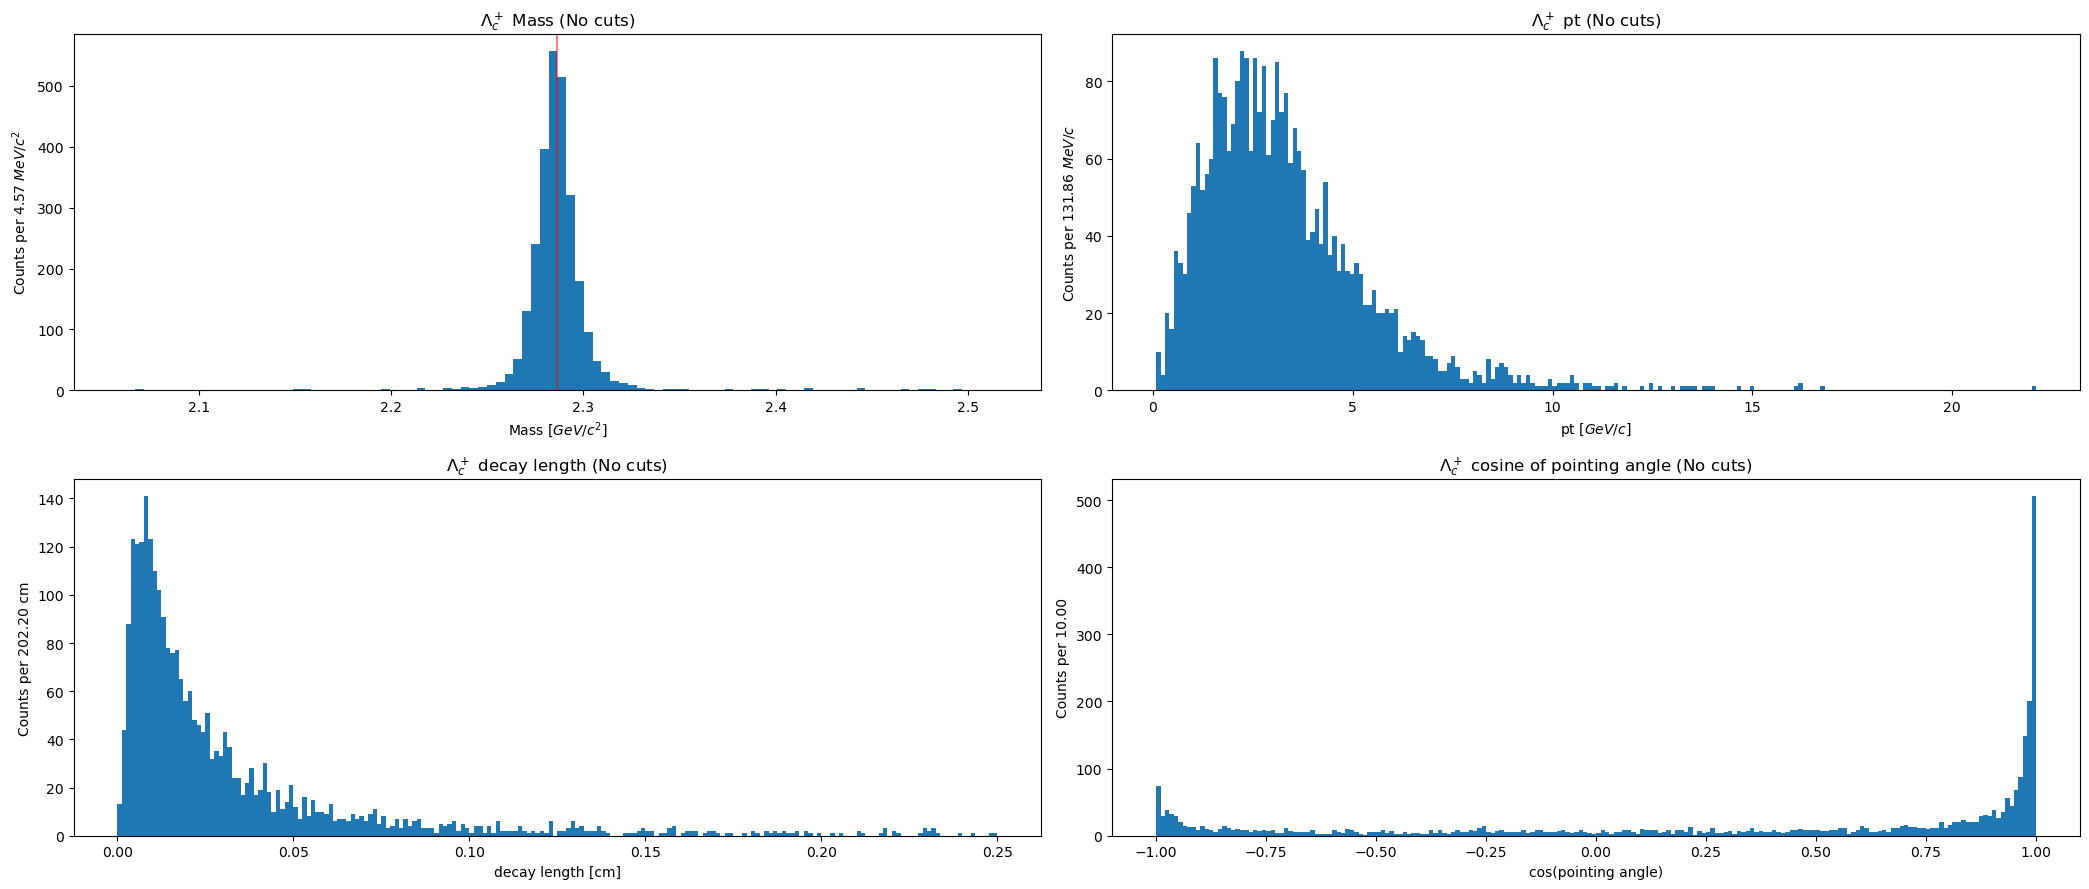

Cosine pointing angle ≥ 0.8: 49.27%
Cosine pointing angle ≥ 0.9: 41.32%
Cosine pointing angle ≥ 0.95: 34.46%
Cosine pointing angle ≥ 0.99: 17.26%


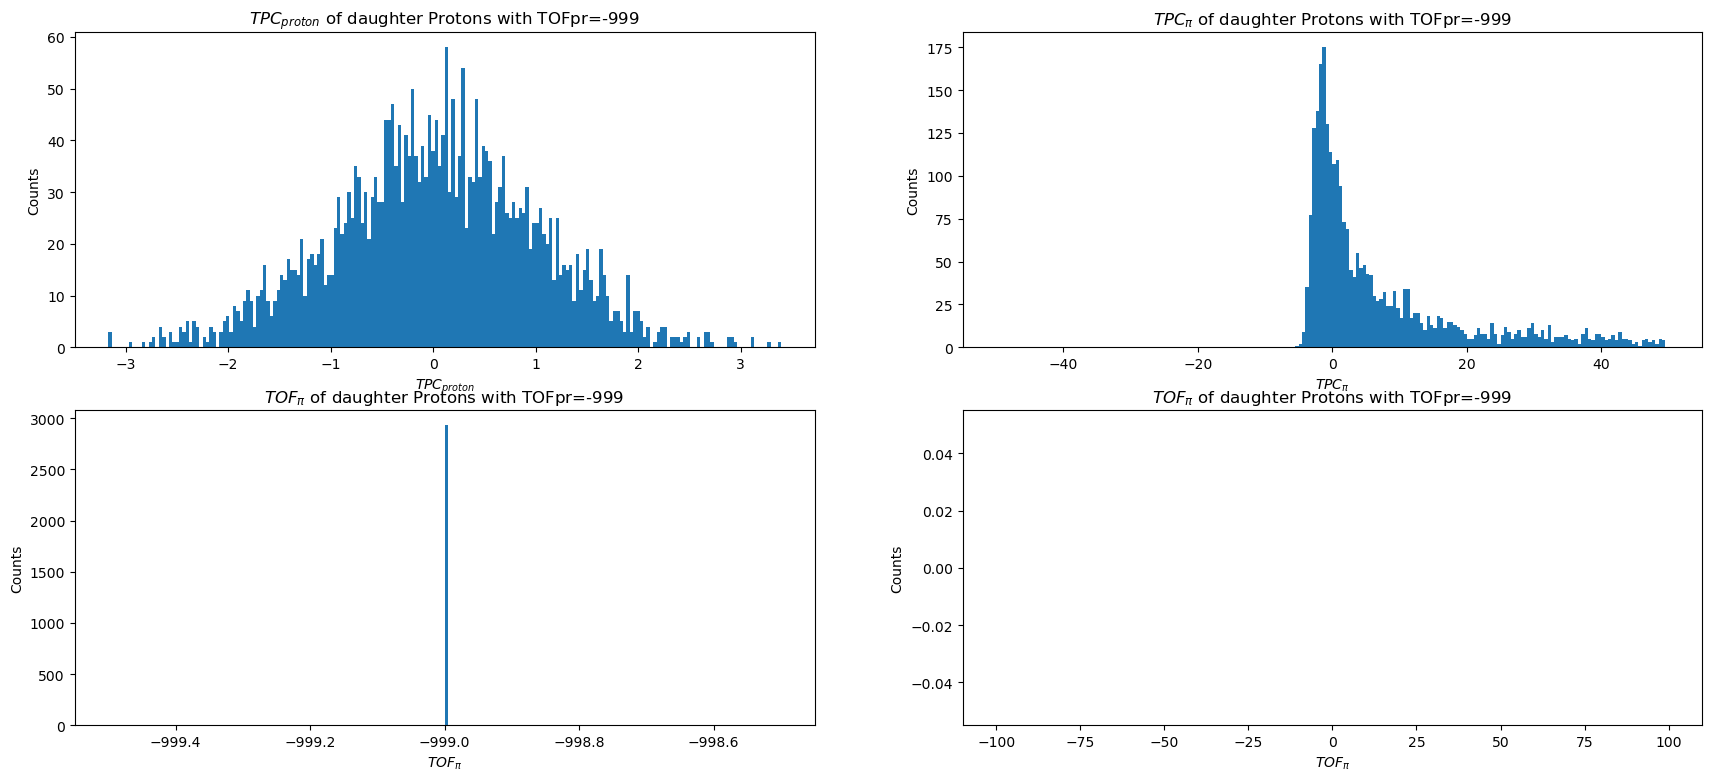

Protons with unavailable TOF crosschecked with TPCpi:
-5 ≤ TPCpi ≤ 5:     56.64%
-3 ≤ TPCpi ≤ 3:     45.96%
-1 ≤ TPCpi ≤ 1:     15.69%


In [17]:
unavailable_TOF_proton = np.isclose(np.where(df["PDG_1"]==2212, df["TOFpr_1"], df["TOFpr_3"]),-999)
df_TOFpr999 = df[unavailable_TOF_proton]
df_TOFpr999

fig, ax = plt.subplots(2,2, figsize=(21,9))
MIN_MASS, MAX_MASS = 0.9*m_lambda, 1.1*m_lambda
N_BINS = 100
ax[0][0].hist(df_TOFpr999["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0][0].axvline(x=m_lambda, color="red", alpha=0.5)
ax[0][0].set_xlabel("Mass [$GeV/c^2$]")
ax[0][0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0][0].set_title(r"$\Lambda^+_c$ Mass (No cuts)")

N_BINS = 200
ax[0][1].hist(df_TOFpr999["pt"], bins=N_BINS)
ax[0][1].set_xlabel("pt [$GeV/c$]")
ax[0][1].set_ylabel(f"Counts per {((df["pt"].max()-df["pt"].min())/N_BINS)*1000:.2f} $MeV/c$")
ax[0][1].set_title(r"$\Lambda^+_c$ pt (No cuts)")

N_BINS = 200
MAX_DL = 0.25
ax[1][0].hist(df_TOFpr999["decay_length"], bins=N_BINS,range=(0, MAX_DL))
ax[1][0].set_xlabel("decay length [cm]")
ax[1][0].set_ylabel(f"Counts per {((df["decay_length"].max()-0)/N_BINS)*1000:.2f} cm")
ax[1][0].set_title(r"$\Lambda^+_c$ decay length (No cuts)")


ax[1][1].hist(df_TOFpr999["cos_pointing"], bins=N_BINS,range=(-1, 1))
ax[1][1].set_xlabel("cos(pointing angle)")
ax[1][1].set_ylabel(f"Counts per {((2)/N_BINS)*1000:.2f}")
ax[1][1].set_title(r"$\Lambda^+_c$ cosine of pointing angle (No cuts)")
plt.tight_layout()
plt.show()

COS_THRESHOLD = [0.80,0.90, 0.95, 0.99]
for i in range (len(COS_THRESHOLD)):
    print(f"Cosine pointing angle ≥ {COS_THRESHOLD[i]}: {((df_TOFpr999["cos_pointing"]>=COS_THRESHOLD[i]).sum()/len(df_TOFpr999)*100):.2f}%")

fig, ax = plt.subplots(2,2,figsize=(21,9))
ax[0][0].hist( np.where(df_TOFpr999["PDG_1"]==2212, df_TOFpr999["TPCpr_1"], df_TOFpr999["TPCpr_3"]), bins=N_bin )
ax[0][0].set_title(r"$TPC_{proton}$ of daughter Protons with TOFpr=-999")
ax[0][0].set_xlabel(r"$TPC_{proton}$")
ax[0][0].set_ylabel(f"Counts")

ax[0][1].hist( np.where(df_TOFpr999["PDG_1"]==2212, df_TOFpr999["TPCpi_1"], df_TOFpr999["TPCpi_3"]), bins=N_bin, range=(-50,50) )
ax[0][1].set_title(r"$TPC_{\pi}$ of daughter Protons with TOFpr=-999")
ax[0][1].set_xlabel(r"$TPC_{\pi}$")
ax[0][1].set_ylabel(f"Counts")

ax[1][0].hist( np.where(df_TOFpr999["PDG_1"]==2212, df_TOFpr999["TOFpi_1"], df_TOFpr999["TOFpi_3"]), bins=N_bin )
ax[1][0].set_title(r"$TOF_{\pi}$ of daughter Protons with TOFpr=-999")
ax[1][0].set_xlabel(r"$TOF_{\pi}$")
ax[1][0].set_ylabel(f"Counts")

ax[1][1].hist( np.where(df_TOFpr999["PDG_1"]==2212, df_TOFpr999["TOFpi_1"], df_TOFpr999["TOFpi_3"]), bins=N_bin, range=(-100,100) )
ax[1][1].set_title(r"$TOF_{\pi}$ of daughter Protons with TOFpr=-999")
ax[1][1].set_xlabel(r"$TOF_{\pi}$")
ax[1][1].set_ylabel(f"Counts")

plt.show()

print("Protons with unavailable TOF crosschecked with TPCpi:")
TPC_THR = [5,3,1]
for i in range(len(TPC_THR)):
    print(f"{-TPC_THR[i]} ≤ TPCpi ≤ {TPC_THR[i]}: \
    {sum(np.abs(np.where(df_TOFpr999["PDG_1"]==2212, df_TOFpr999["TPCpi_1"], df_TOFpr999["TPCpi_3"]))<=TPC_THR[i]) \
    /len(df_TOFpr999)*100:.2f}%")
    


### Pions

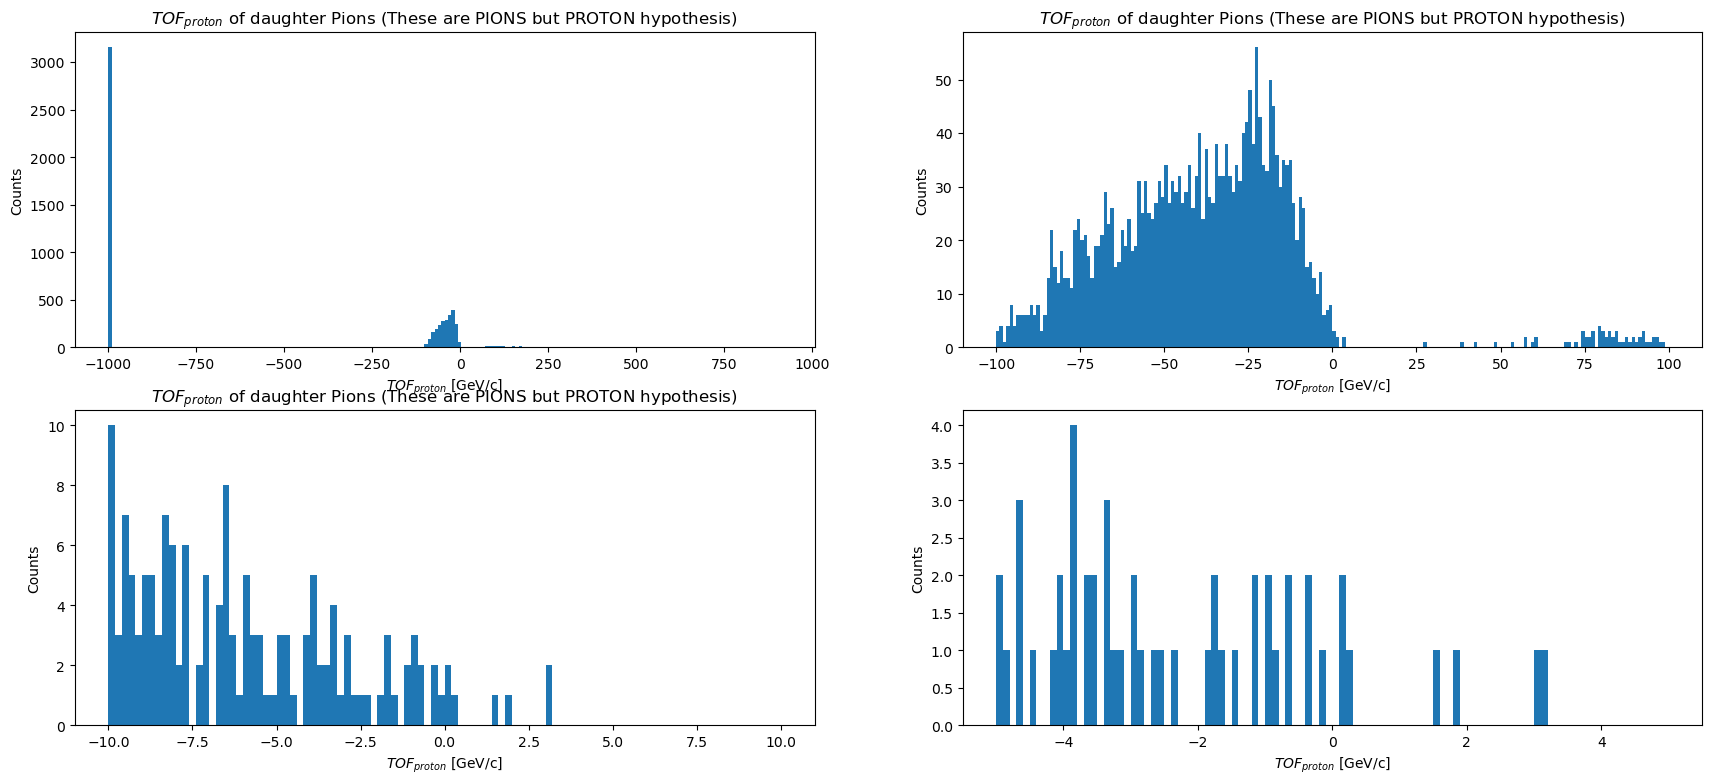

The fraction of PIONS with unavailable TOFpi is: 55.39%
 -10 ≤ TOFpi ≤ 10: 40.01%
 -5 ≤ TOFpi ≤ 5: 34.55%
 -3 ≤ TOFpi ≤ 3: 26.47%

Out of those with TOF within 10 sigmas
 -5 ≤ TOFpi ≤ 5: 86.35%
 -3 ≤ TOFpi ≤ 3: 66.17%

The fraction of PIONS with unavailable TOFpr is: 55.39%
For these particles (Truth=Pion, but proton hyp): of those with |TOFpr| within 100 sigmas
 -100 ≤ TOFpr ≤ 100: 100.00%
 -50 ≤ TOFpr ≤ 50: 63.86%
 -25 ≤ TOFpr ≤ 25: 29.94%
 -10 ≤ TOFpr ≤ 10: 6.29%
 -5 ≤ TOFpr ≤ 5: 2.18%
 -3 ≤ TOFpr ≤ 3: 1.09%
 -1 ≤ TOFpr ≤ 1: 0.46%


In [18]:
# these are pions(211) but I check the variables relative to protons to see if they are easy to spot
# Let's see some properties for pions
N_bin = 200
fig, ax = plt.subplots(2,2, figsize=(21,9))
ax[0][0].hist(np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"]), bins=N_bin)
ax[0][0].set_title(r"$TOF_{proton}$ of daughter Pions (These are PIONS but PROTON hypothesis)")
ax[0][0].set_xlabel(r"$TOF_{proton}$ [GeV/c]")
ax[0][0].set_ylabel(f"Counts")

ax[0][1].hist(np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"]), bins=N_bin, range=(-100,100))
ax[0][1].set_title(r"$TOF_{proton}$ of daughter Pions (These are PIONS but PROTON hypothesis)")
ax[0][1].set_xlabel(r"$TOF_{proton}$ [GeV/c]")
ax[0][1].set_ylabel(f"Counts")

ax[1][0].hist(np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"]), bins=N_bin//2, range=(-10,10))
ax[1][0].set_title(r"$TOF_{proton}$ of daughter Pions (These are PIONS but PROTON hypothesis)")
ax[1][0].set_xlabel(r"$TOF_{proton}$ [GeV/c]")
ax[1][0].set_ylabel(f"Counts")

ax[1][1].hist(np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"]), bins=N_bin//2, range=(-5,5))
ax[1][1].set_xlabel(r"$TOF_{proton}$ [GeV/c]")
ax[1][1].set_ylabel(f"Counts")
plt.show()


# Let's crunch some numbers
print("The fraction of PIONS with unavailable TOFpi is: "+
     f"{(sum(np.isclose((np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"])),-999)))/len(df)*100:.2f}%")

TOF_MAX = [10,5,3]
for i in range (len(TOF_MAX)): 
    print(f" {-TOF_MAX[i]} ≤ TOFpi ≤ {TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"])) < TOF_MAX[i]))/len(df)*100:.2f}%")

print("\nOut of those with TOF within 10 sigmas")
for i in [1,len(TOF_MAX)-1]: 
    print(f" {-TOF_MAX[i]} ≤ TOFpi ≤ {TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"])) < TOF_MAX[i]))
    /(sum(np.abs(np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]))<=10))*100:.2f}%")

print("\nThe fraction of PIONS with unavailable TOFpr is: "+
     f"{(sum(np.isclose((np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"])),-999)))/len(df)*100:.2f}%")
EX_TOF_MAX = [100,50,25,10,5,3,1]
print("For these particles (Truth=Pion, but proton hyp): of those with |TOFpr| within 100 sigmas")
for i in range (len(EX_TOF_MAX)): 
    print(f" {-EX_TOF_MAX[i]} ≤ TOFpr ≤ {EX_TOF_MAX[i]}: {sum((np.abs(np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"])) < EX_TOF_MAX[i]))
                                                             /(sum(np.abs(np.where(df["PDG_1"]==211, df["TOFpr_1"], df["TOFpr_3"]))<=100))*100:.2f}%")

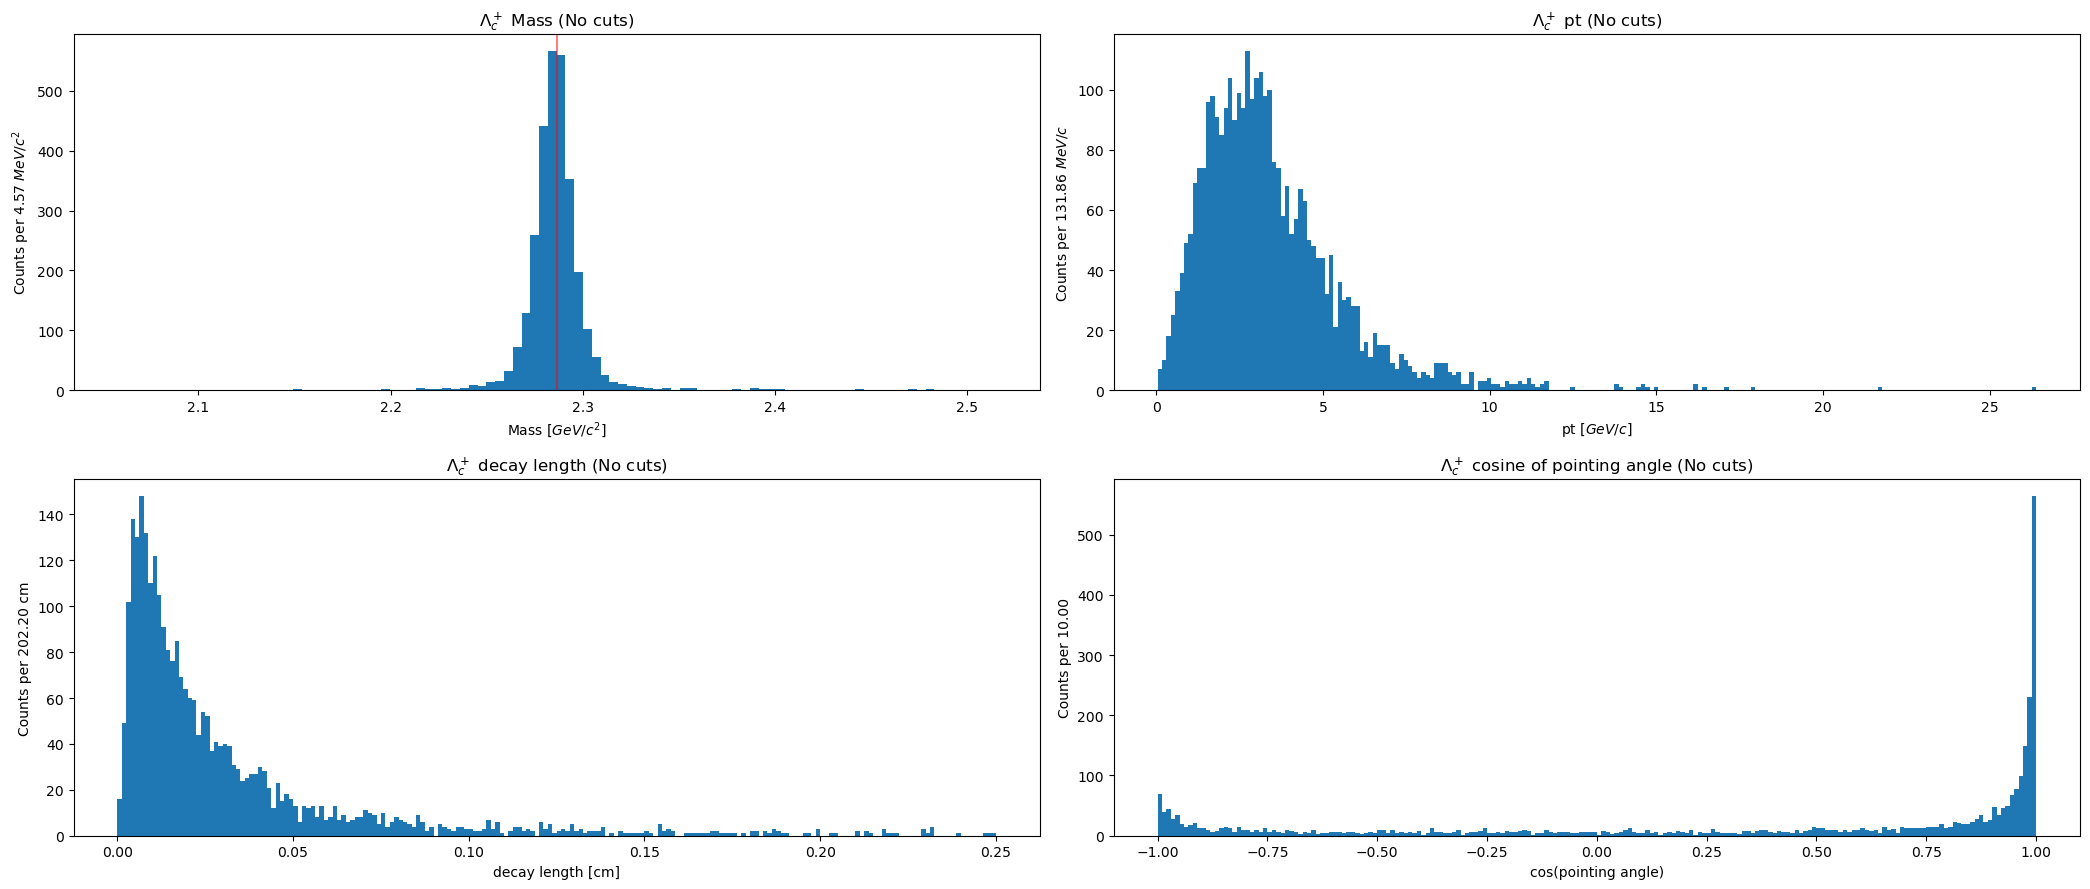

Cosine pointing angle ≥ 0.8: 50.62%
Cosine pointing angle ≥ 0.9: 43.30%
Cosine pointing angle ≥ 0.95: 35.50%
Cosine pointing angle ≥ 0.99: 17.88%


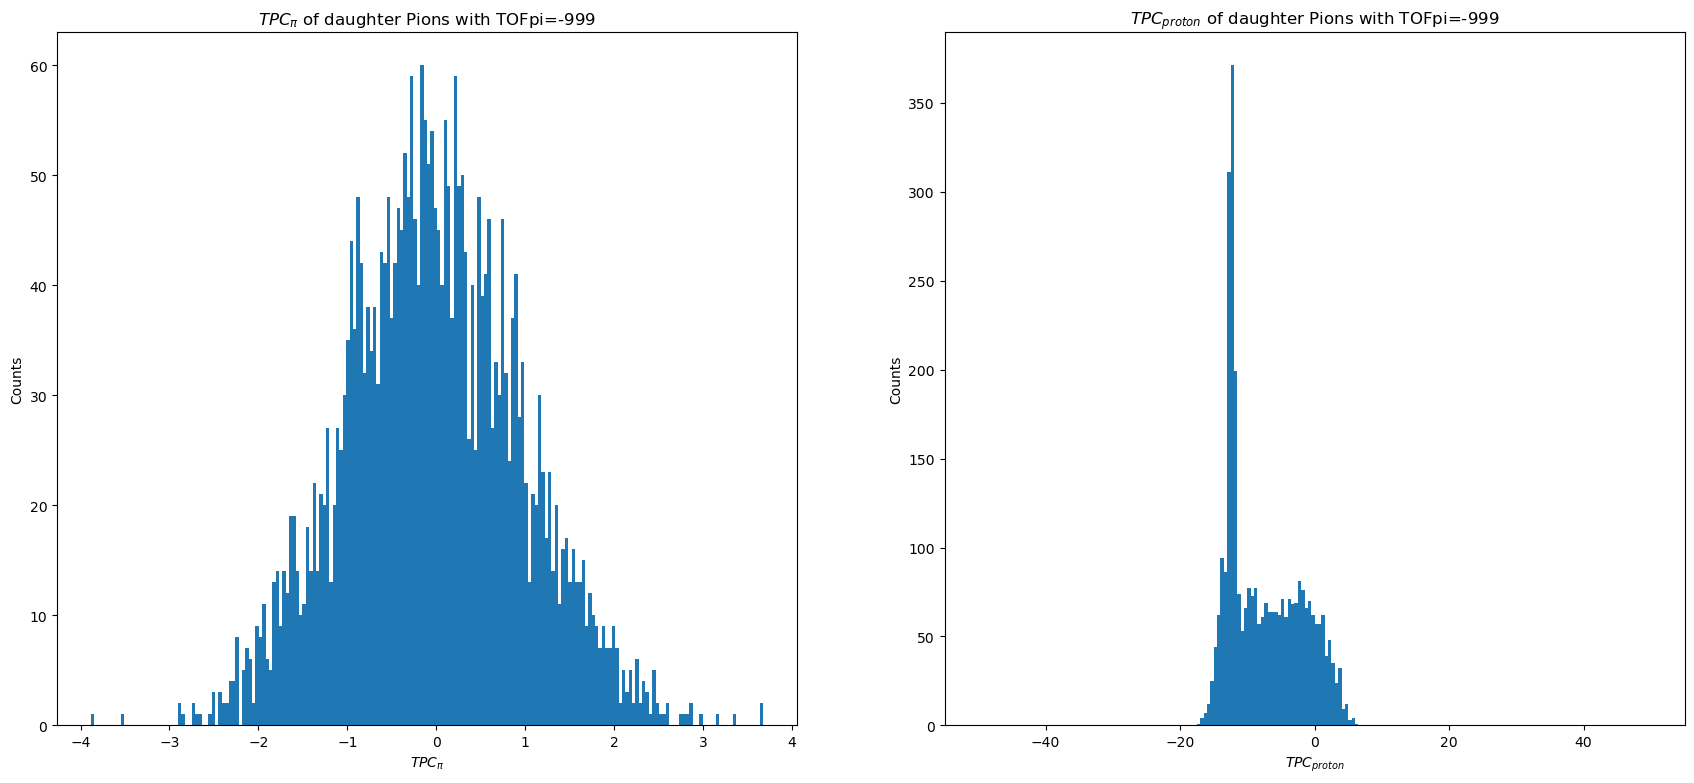

Pions with unavailable TOF crosschecked with TPCpr:
-5 ≤ TPCpr ≤ 5:     33.91%
-3 ≤ TPCpr ≤ 3:     22.88%
-1 ≤ TPCpr ≤ 1:     7.80%


In [19]:
unavailable_TOF_pion = np.isclose(np.where(df["PDG_1"]==211, df["TOFpi_1"], df["TOFpi_3"]),-999)
df_TOFpi999 = df[unavailable_TOF_pion]
df_TOFpi999

fig, ax = plt.subplots(2,2, figsize=(21,9))
MIN_MASS, MAX_MASS = 0.9*m_lambda, 1.1*m_lambda
N_BINS = 100
ax[0][0].hist(df_TOFpi999["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0][0].axvline(x=m_lambda, color="red", alpha=0.5)
ax[0][0].set_xlabel("Mass [$GeV/c^2$]")
ax[0][0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0][0].set_title(r"$\Lambda^+_c$ Mass (No cuts)")

N_BINS = 200
ax[0][1].hist(df_TOFpi999["pt"], bins=N_BINS)
ax[0][1].set_xlabel("pt [$GeV/c$]")
ax[0][1].set_ylabel(f"Counts per {((df["pt"].max()-df["pt"].min())/N_BINS)*1000:.2f} $MeV/c$")
ax[0][1].set_title(r"$\Lambda^+_c$ pt (No cuts)")

N_BINS = 200
MAX_DL = 0.25
ax[1][0].hist(df_TOFpi999["decay_length"], bins=N_BINS,range=(0, MAX_DL))
ax[1][0].set_xlabel("decay length [cm]")
ax[1][0].set_ylabel(f"Counts per {((df["decay_length"].max()-0)/N_BINS)*1000:.2f} cm")
ax[1][0].set_title(r"$\Lambda^+_c$ decay length (No cuts)")


ax[1][1].hist(df_TOFpi999["cos_pointing"], bins=N_BINS,range=(-1, 1))
ax[1][1].set_xlabel("cos(pointing angle)")
ax[1][1].set_ylabel(f"Counts per {((2)/N_BINS)*1000:.2f}")
ax[1][1].set_title(r"$\Lambda^+_c$ cosine of pointing angle (No cuts)")
plt.tight_layout()
plt.show()

COS_THRESHOLD = [0.80,0.90, 0.95, 0.99]
for i in range (len(COS_THRESHOLD)):
    print(f"Cosine pointing angle ≥ {COS_THRESHOLD[i]}: {((df_TOFpi999["cos_pointing"]>=COS_THRESHOLD[i]).sum()/len(df_TOFpi999)*100):.2f}%")

fig, ax = plt.subplots(1,2,figsize=(21,9))
ax[0].hist( np.where(df_TOFpi999["PDG_1"]==211, df_TOFpi999["TPCpi_1"], df_TOFpi999["TPCpi_3"]), bins=N_bin )
ax[0].set_title(r"$TPC_{\pi}$ of daughter Pions with TOFpi=-999")
ax[0].set_xlabel(r"$TPC_{\pi}$")
ax[0].set_ylabel(f"Counts")

ax[1].hist( np.where(df_TOFpi999["PDG_1"]==211, df_TOFpi999["TPCpr_1"], df_TOFpi999["TPCpr_3"]), bins=N_bin, range=(-50,50) )
ax[1].set_title(r"$TPC_{proton}$ of daughter Pions with TOFpi=-999")
ax[1].set_xlabel(r"$TPC_{proton}$")
ax[1].set_ylabel(f"Counts")
plt.show()

print("Pions with unavailable TOF crosschecked with TPCpr:")
TPC_THR = [5,3,1]
for i in range(len(TPC_THR)):
    print(f"{-TPC_THR[i]} ≤ TPCpr ≤ {TPC_THR[i]}: \
    {sum(np.abs(np.where(df_TOFpi999["PDG_1"]==211, df_TOFpi999["TPCpr_1"], df_TOFpi999["TPCpr_3"]))<=TPC_THR[i]) \
    /len(df_TOFpi999)*100:.2f}%")

## Kaons

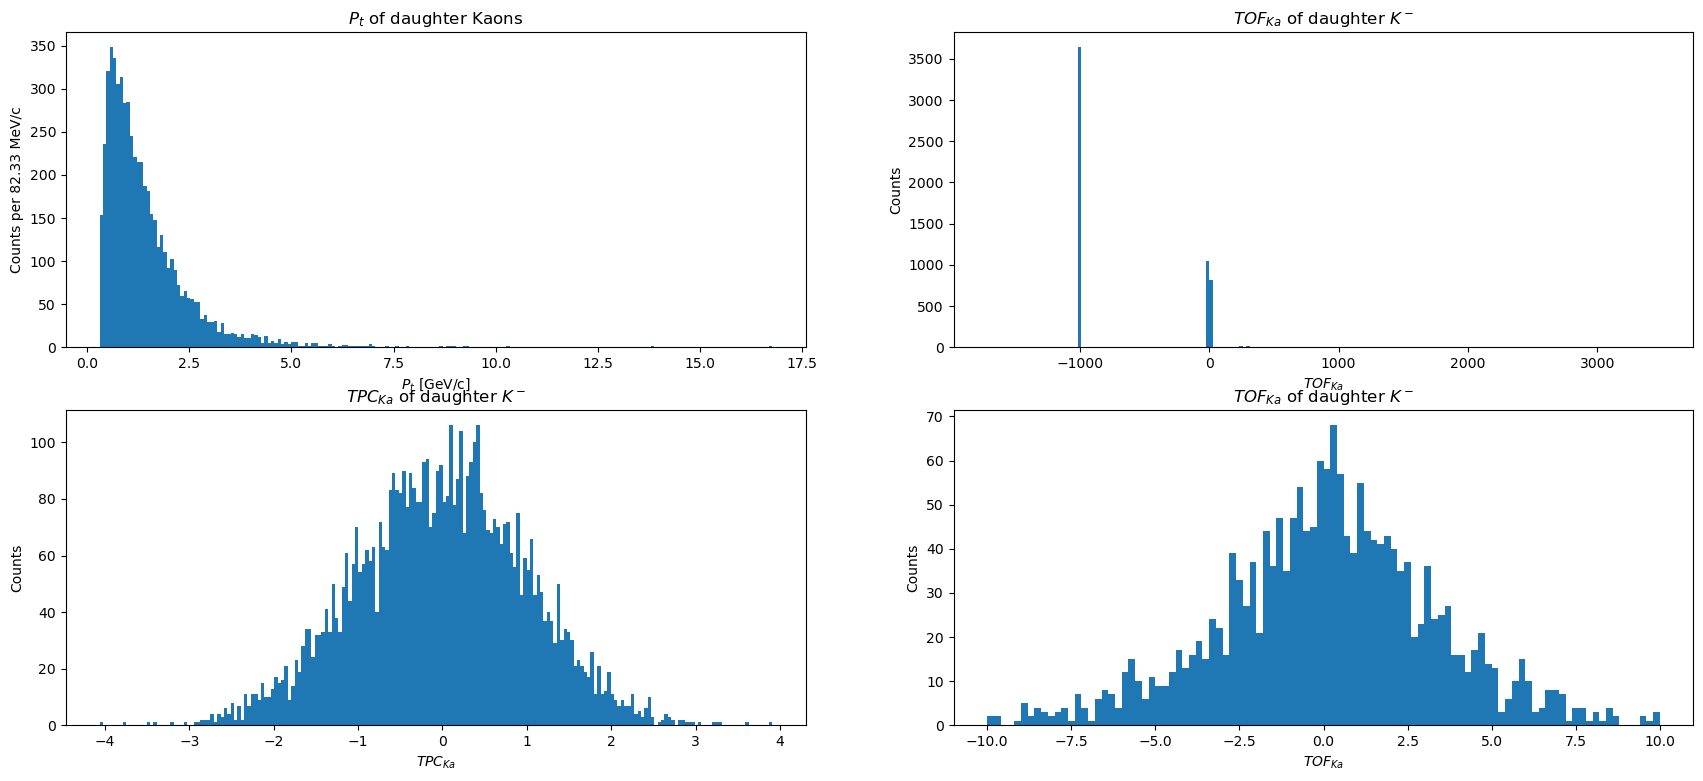

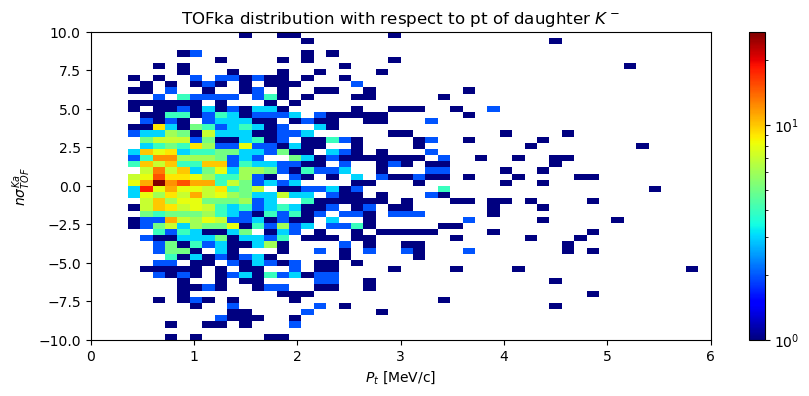

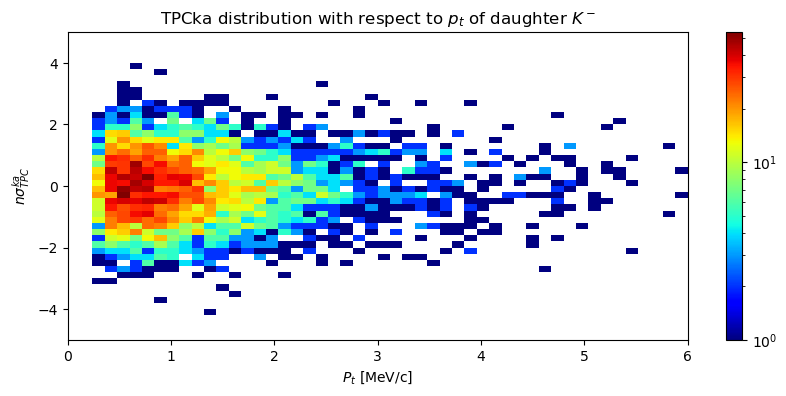

 -10 ≤ TOFka ≤ 10: 32.08%
 -5 ≤ TOFka ≤ 5: 27.98%
 -3 ≤ TOFka ≤ 3: 21.59%


In [57]:
# Let's see some properties for negative kaons
N_bin = 200
fig, ax = plt.subplots(2,2, figsize=(21,9))
pt_ka = df["pt_2"]
ax[0][0].hist(pt_pr, bins=N_bin)
ax[0][0].set_title(f"$P_t$ of daughter Kaons")
ax[0][0].set_xlabel(f"$P_t$ [GeV/c]")
ax[0][0].set_ylabel(f"Counts per {((max(pt_pr)-min(pt_pr))/N_bin*1000):.2f} MeV/c")

ax[0][1].hist( df["TOFka"], bins=N_bin )
ax[0][1].set_title(r"$TOF_{Ka}$ of daughter $K^-$")
ax[0][1].set_xlabel(r"$TOF_{Ka}$")
ax[0][1].set_ylabel(f"Counts")

ax[1][1].hist( df["TOFka"], bins=N_bin//2, range=(-10,10) )
ax[1][1].set_title(r"$TOF_{Ka}$ of daughter $K^-$")
ax[1][1].set_xlabel(r"$TOF_{Ka}$")
ax[1][1].set_ylabel(f"Counts")

ax[1][0].hist( df["TPCka"], bins=N_bin )
ax[1][0].set_title(r"$TPC_{Ka}$ of daughter $K^-$")
ax[1][0].set_xlabel(r"$TPC_{Ka}$")
ax[1][0].set_ylabel(f"Counts")

plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(pt_ka, df["TOFka"], (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-10,10]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{Ka}_{TOF}$")
plt.title(r"TOFka distribution with respect to pt of daughter $K^-$")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plt.hist2d(pt_ka, df["TPCka"], (50, 50), cmap="jet",norm=LogNorm(), range=([0,6],[-5,5]) )
plt.colorbar()
plt.xlabel(r"$P_t$ [MeV/c]")
plt.ylabel(r"$n\sigma^{ka}_{TPC}$")
plt.title(r"TPCka distribution with respect to $p_t$ of daughter $K^-$")
plt.show()

TOF_MAX = [10,5,3]
for i in range (len(TOF_MAX)): 
    print(f" {-TOF_MAX[i]} ≤ TOFka ≤ {TOF_MAX[i]}: {sum((np.abs(df["TOFka"]) < TOF_MAX[i]))/len(df)*100:.2f}%")

# Conclusions

## Protons

Proton1 Mask efficiency: 72.22%


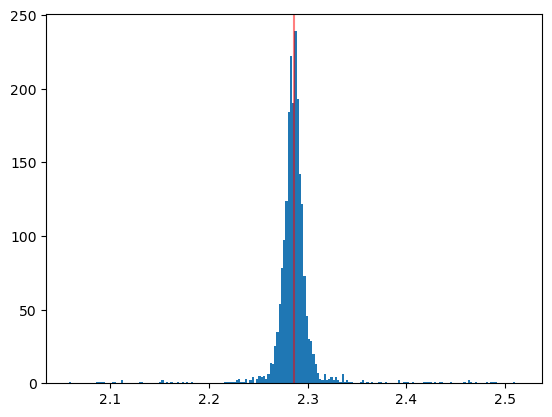

This mask mistakenly identifies as pions the following percentage of the data: 0.22%
Proton3 Mask efficiency: 61.25%


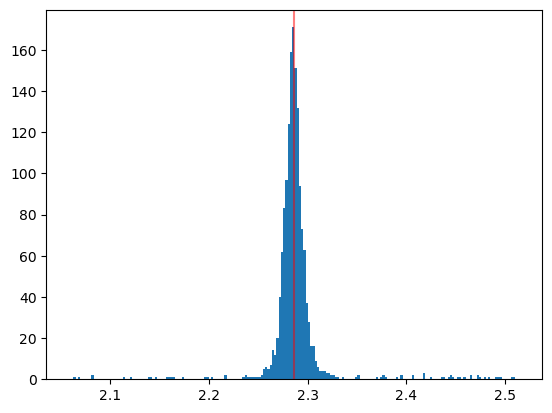

This mask mistakenly identifies as pions the following percentage of the data: 0.07%
Average proton mask efficiency: 66.73%


In [48]:
# Let's see if the following filters are properly identifying the particles
# charge is already taken care of
#pr_charge = final_results["fCharge"]==+1
pr_TCP_mask_1 = final_results["TPCpr_1"].between(-3,3) & 
pr_TOF_mask_1 = ( final_results["TOFpr_1"].between(-5,5) & (final_results["TOFpi_1"].abs() > 5) ) | \
                ( np.isclose(final_results["TOFpr_1"], -999) & (final_results["TPCpi_1"].abs() > 3))
pr_mask_1 = pr_TCP_mask_1 & pr_TOF_mask_1
pr_mask_1_efficiency = len(final_results[pr_mask_1])/(sum(final_results["PDG_1"]==2212))
print(f"Proton1 Mask efficiency: {pr_mask_1_efficiency*100:.2f}%")

plt.hist(final_results[pr_mask_1]["inv_mass"], bins=200, range=(0.9*m_lambda, 1.1*m_lambda ) )
plt.axvline(x=m_lambda, color="red", alpha=0.5)
plt.show()
print("This mask mistakenly identifies as pions the following percentage of the data: " +
f"{sum(final_results[pr_mask_1]["PDG_1"]==211)/len(final_results)*100:.2f}%")

pr_TCP_mask_3 = final_results["TPCpr_3"].between(-3,3)
pr_TOF_mask_3 = ( final_results["TOFpr_3"].between(-5,5) & (final_results["TOFpi_3"].abs() > 5) ) | \
                ( np.isclose(final_results["TOFpr_3"], -999) & (final_results["TPCpi_3"].abs() > 3))
pr_mask_3 = pr_TCP_mask_3 & pr_TOF_mask_3
pr_mask_3_efficiency = len(final_results[pr_mask_3])/(sum(final_results["PDG_3"]==2212))
print(f"Proton3 Mask efficiency: {pr_mask_3_efficiency*100:.2f}%")

plt.hist(final_results[pr_mask_3]["alt_mass"], bins=200, range=(0.9*m_lambda, 1.1*m_lambda ) )
plt.axvline(x=m_lambda, color="red", alpha=0.5)
plt.show()
print("This mask mistakenly identifies as pions the following percentage of the data: " +
f"{sum(final_results[pr_mask_3]["PDG_3"]==211)/len(final_results)*100:.2f}%")

print(f"Average proton mask efficiency: {((pr_mask_1_efficiency+pr_mask_3_efficiency)/2)*100:.2f}%" )

## Pions

Pion1 Mask efficiency: 76.81%


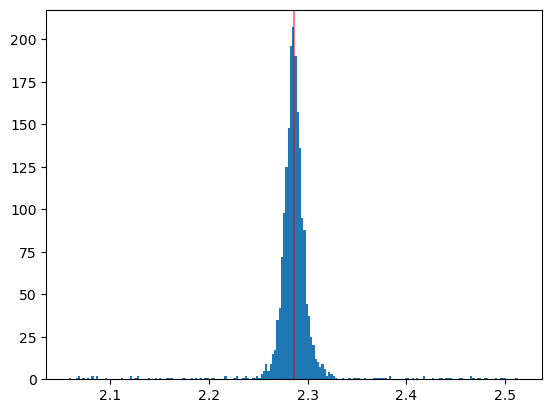

This mask mistakenly identifies as protons the following percentage of the data: 0.30%
Pion3 Mask efficiency: 77.77%


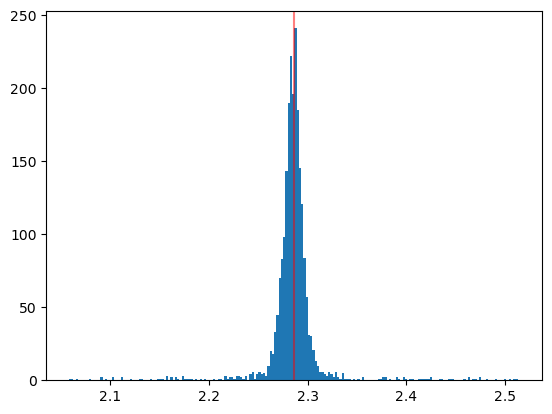

This mask mistakenly identifies as protons the following percentage of the data: 0.13%
Average proton mask efficiency: 77.29%


In [53]:
# charge is already taken care of
#pi_charge = final_results["fCharge"]==+1
pi_TCP_mask_1 = final_results["TPCpi_1"].between(-3,3)
pi_TOF_mask_1 = ( final_results["TOFpi_1"].between(-5,5) & (final_results["TOFpr_1"].abs() > 5) ) | \
                ( np.isclose(final_results["TOFpi_1"], -999) & (final_results["TPCpr_1"].abs() > 3))
pi_mask_1 = pi_TCP_mask_1 & pi_TOF_mask_1
pi_mask_1_efficiency = len(final_results[pi_mask_1])/(sum(final_results["PDG_1"]==211))
print(f"Pion1 Mask efficiency: {pi_mask_1_efficiency*100:.2f}%")

plt.hist(final_results[pi_mask_1]["alt_mass"], bins=200, range=(0.9*m_lambda, 1.1*m_lambda ) )
plt.axvline(x=m_lambda, color="red", alpha=0.5)
plt.show()
print("This mask mistakenly identifies as protons the following percentage of the data: " +
f"{sum(final_results[pi_mask_1]["PDG_1"]==2212)/len(final_results)*100:.2f}%")

pi_TCP_mask_3 = final_results["TPCpi_3"].between(-3,3)
pi_TOF_mask_3 = ( final_results["TOFpi_3"].between(-5,5) & (final_results["TOFpr_3"].abs() > 5) ) | \
                ( np.isclose(final_results["TOFpi_3"], -999) & (final_results["TPCpr_3"].abs() > 3))
pi_mask_3 = pi_TCP_mask_3 & pi_TOF_mask_3
pi_mask_3_efficiency = len(final_results[pi_mask_3])/(sum(final_results["PDG_3"]==211))
print(f"Pion3 Mask efficiency: {pi_mask_3_efficiency*100:.2f}%")

plt.hist(final_results[pi_mask_3]["inv_mass"], bins=200, range=(0.9*m_lambda, 1.1*m_lambda ) )
plt.axvline(x=m_lambda, color="red", alpha=0.5)
plt.show()
print("This mask mistakenly identifies as protons the following percentage of the data: " +
f"{sum(final_results[pi_mask_3]["PDG_3"]==2212)/len(final_results)*100:.2f}%")

print(f"Average proton mask efficiency: {((pi_mask_1_efficiency+pi_mask_3_efficiency)/2)*100:.2f}%" )